<a href="https://colab.research.google.com/github/ecloguehwang/2026-Seojinhyeop-Workshop/blob/main/%ED%95%A9%EB%B6%88%EC%9E%90%EB%A3%8C%EC%A0%95%EB%A6%AC_%EB%8C%80%ED%95%99%EA%B5%90%EA%B0%80%EC%95%84%EB%8B%8C%EB%8C%80%EB%A1%9C%EB%81%9D%EB%82%98%EB%8A%94%ED%95%99%EA%B5%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#'~대'로 끝나는 합불자료

In [ ]:
#colab에서 matplotlib와 sns 라이브러리 그래프 한글을 깨지지 않게 하는 법A: 이 코드실행하고 런타임(runtime) 다시 실행하기
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

In [ ]:
#pandas, openpyxl 라이브러리 부르기
import pandas as pd
import numpy as np
from tabulate import tabulate
import matplotlib.pyplot as plt


#matplotlib에서 한글구현
plt.rc('font', family='NanumBarunGothic')

#그래프 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False



##  데이터 부르기
path = '/content/drive/MyDrive/python/habbul/'
df = pd.read_excel(f'{path}eunpyeong_2025_habbul.xlsx')


# 첫 5줄을 봅니다.
df.tail(2)

In [ ]:
#합불자료 인원: 122명

df_number = df.drop_duplicates('이름')
df_number = len(df_number)
print(df_number)

122


In [ ]:
#중복제외한 합격률 76%

#중복제외한 수능응시자수
df_number = df.drop_duplicates('이름')
df_number = len(df_number)

#합격자
df_pass = df[df.최종 == '합']


#중복제외한 합격자수
df_pass_noduplicate = df_pass.drop_duplicates('이름')

#중복제외한 합격자 비율
df_pass_noduplicate_ratio = (len(df_pass_noduplicate) / df_number) * 100


#소수점 첫째자리에 반올림
df_pass_noduplicate_ratio = int(round(df_pass_noduplicate_ratio, 0))


print(f'중복제외한 합격자수는 {df_pass_noduplicate_ratio}%')

In [ ]:
#중복제외한 수능 합격률 76%

#중복제외한 수능응시자수
df_number = df.drop_duplicates('이름')
df_number = len(df_number)

#합격자
df_pass = df[df.최종 == '합']


#중복제외한 합격자수
df_pass_noduplicate = df_pass.drop_duplicates('이름')

#이름, 대학, 모집단위
df_pass_noduplicate = df_pass_noduplicate[['이름', '대학', '모집단위', '최종']]

df_pass_noduplicate

In [ ]:
#1. 서울주요대(18개대) 대학별 합격자수

import os
import pandas as pd

##  데이터 부르기
path = '/content/drive/MyDrive/python/habbul/'
df = pd.read_excel(f'{path}eunpyeong_2025_habbul.xlsx')


uni = ['서울대', '연세대', '고려대', '서강대', '성균관대', '한양대', '중앙대', '경희대', '한국외대', '서울시립대', '이화여대', '건국대', '동국대', '홍익대',
       '숙명여대', '국민대', '숭실대', '세종대']


# 서울 주요대학 수시합격자수 출력
print("\n***2025학년도 E고 합격건수***")

total_accepted = 0  # Variable to store the total number of accepted students

for u in range(len(uni)):
    df_u = df[(df.대학 == uni[u]) & (df.최종 == '합')]
    accepted_count = len(df_u['대학'])
    total_accepted += accepted_count
    print(uni[u], str(accepted_count) + "건")

print(f"\n총 합격자 수: {total_accepted}건")

In [ ]:
#2.수시, 정시별 서울주요대 합격자 명단

import pandas as pd
import matplotlib.pyplot as plt


#표시할 대학리스트
uni = ['서울대', '연세대', '고려대', '서강대', '성균관대', '한양대', '중앙대', '경희대', '한국외대', '서울시립대', '이화여대', '건국대', '동국대', '홍익대',
       '숙명여대', '국민대', '숭실대', '세종대', '서울과기대', '광운대', '명지대', '상명대', '가톨릭대(성심)', '가천대(글로벌)']


# 데이터 부르기
path = '/content/drive/MyDrive/python/habbul/'
df = pd.read_excel(f'{path}eunpyeong_2025_habbul.xlsx')


# '지원시기'열의 값 변경: 가,나
df['지원시기'] = df['지원시기'].replace({'가': '정시', '나': '정시', '다': '정시',
                                       '수시1차': '수시', '수시2차': '수시'})

# 빈 리스트
uni_new = []
num_su = []
num_je = []


# 리스트에 새로운 대학리스트와, 수시합격자, 정시합격자를 담기
for u in uni:
    df_u = df[(df.대학 == u) & (df.최종 == '합')]
    df_u = df_u[['지원시기', '학번', '대학', '최종']]

    num_su_u = len(df_u[df_u['지원시기'] == '수시'])
    num_je_u = len(df_u[df_u['지원시기'] == '정시'])


    if num_su_u >= 1 or num_je_u >= 1:  # '지원시기'열의 값이 1 이상일 때만 값을 표시
        uni_new.append(u)
        num_su.append(num_su_u)
        num_je.append(num_je_u)

        print(u, "합격자수 - 수시:", str(num_su_u) + "명,", "정시:", str(num_je_u) + "명")
        print("-----------------------------------------\n")

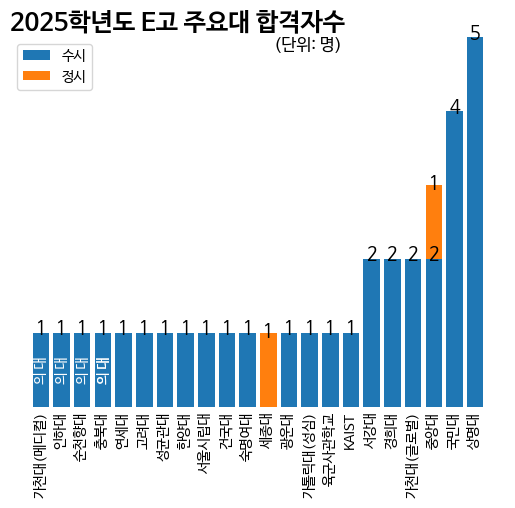

In [ ]:
#3. 서울주요대 합격자수 막대그래프(세로)

import pandas as pd
import matplotlib.pyplot as plt


#표시할 대학리스트
uni = ['가천대(메디컬)', '인하대', '순천향대', '충북대', '서울대', '연세대', '고려대', '서강대', '성균관대', '한양대', '중앙대', '경희대', '한국외대', '서울시립대', '이화여대', '건국대', '동국대', '홍익대',
       '숙명여대', '국민대', '숭실대', '세종대', '서울과기대', '광운대', '명지대', '상명대', '가톨릭대(성심)', '가천대(글로벌)', '육군사관학교', 'GIST', 'DGIST', 'UNIST', 'KAIST']


# 데이터 부르기
path = '/content/drive/MyDrive/python/habbul/'
df = pd.read_excel(f'{path}eunpyeong_2025_habbul.xlsx')


# '지원시기'열의 값 변경: 가,나
df['지원시기'] = df['지원시기'].replace({'가': '정시', '나': '정시', '다': '정시',
                                       '수시1차': '수시', '수시2차': '수시'})

# 빈 리스트
uni_new = []
num_su = []
num_je = []


# 리스트에 새로운 대학리스트와, 수시합격자, 정시합격자를 담기
for u in uni:
    df_u = df[(df.대학 == u) & (df.최종 == '합')]
    df_u = df_u[~((df_u['대학'] == '대구가톨릭대') & (df_u['모집단위'] == '국어교육과'))]
    df_u = df_u[~((df_u['대학'] == '동덕여대') & (df_u['모집단위'] == '식품영양학전공'))]

    df_u = df_u[['지원시기', '학번', '대학', '최종']]

    num_su_u = len(df_u[df_u['지원시기'] == '수시'])
    num_je_u = len(df_u[df_u['지원시기'] == '정시'])


    if num_su_u >= 1 or num_je_u >= 1:  # '지원시기'열의 값이 1 이상일 때만 값을 표시
        uni_new.append(u)
        num_su.append(num_su_u)
        num_je.append(num_je_u)

        #print(u, "합격자수 - 수시:", str(num_su_u) + "명,", "정시:", str(num_je_u) + "명")
        #print("-----------------------------------------\n")


# 지원시기가 1 이상인 데이터만 사용
num_su = [su for su, je in zip(num_su, num_je) if su >= 1 or je >= 1]
num_je = [je for su, je in zip(num_su, num_je) if su >= 1 or je >= 1]
uni_new = [uni for uni, su, je in zip(uni_new, num_su, num_je) if su >= 1 or je >= 1]


if len(uni_new) > 0:
    # sort the data by the total number of admissions (sum of num_su and num_je)
    data = sorted(zip(uni_new, num_su, num_je), key=lambda x: x[1]+x[2], reverse=False)
    uni_new = [x[0] for x in data]
    num_su = [x[1] for x in data]
    num_je = [x[2] for x in data]

    # plot the bar graph
    fig, ax = plt.subplots()
    ax.bar(uni_new, num_su, label='수시')
    ax.bar(uni_new, num_je, bottom=num_su, label='정시')


    # add value labels
    for i, (su, je) in enumerate(zip(num_su, num_je)):
        if su >= 1:
            ax.text(i, su+0.05, su, ha='center', va='center', fontsize=13)
        if je >= 1:
            ax.text(i, su + je+0.02, je, ha='center', va='center', fontsize=13)



    # Add '의예과' label for '가천대(메디컬)'
    for i, (uni, su, je) in enumerate(zip(uni_new, num_su, num_je)):
        if uni == '가천대(메디컬)' and '의예과' not in uni_new:
            ax.text(i+0.08, su - 0.5, '의 대', ha='center', va='center', fontsize=10, color='white', rotation=90)



    # Add '의예과' label for '인하대'
    for i, (uni, su, je) in enumerate(zip(uni_new, num_su, num_je)):
        if uni == '인하대' and '의예과' not in uni_new:
            ax.text(i+0.08, su - 0.5, '의 대', ha='center', va='center', fontsize=10, color='white', rotation=90)



    # Add '의예과' label for '순천향대'
    for i, (uni, su, je) in enumerate(zip(uni_new, num_su, num_je)):
        if uni == '순천향대' and '의예과' not in uni_new:
            ax.text(i+0.08, su - 0.5, '의 대', ha='center', va='center', fontsize=10, color='white', rotation=90)


    # Add '의예과' label for '충북대'
    for i, (uni, su, je) in enumerate(zip(uni_new, num_su, num_je)):
        if uni == '충북대' and '의예과' not in uni_new:
            ax.text(i+0.08, su - 0.5, '의 대', ha='center', va='center', fontsize=10, color='white', rotation=90)


    # Add '의예과' label for '충북대'
    for i, (uni, su, je) in enumerate(zip(uni_new, num_su, num_je)):
        if uni == '충북대' and '의예과' not in uni_new:
            ax.text(i+0.08, su - 0.5, '의 대', ha='center', va='center', fontsize=10, color='white', rotation=90)



    # Add '육사' label for '육사'
    #for i, (uni, su, je) in enumerate(zip(uni_new, num_su, num_je)):
        #if uni == '육군사관학교' and '육군사관학교(인문)(남)' not in uni_new:
            #ax.text(i+0.08, su - 0.5, '육사', ha='center', va='center', fontsize=10, color='white', rotation=90)

    # 범례
    ax.legend()

    # 그래프 제목
    ax.set_title('2025학년도 E고 주요대 합격자수', fontsize=18, fontweight='bold', loc='left')

    # 그래프 부제목
    ax.text(0.6, 1.00, '(단위: 명)', ha='center', va='top', transform=ax.transAxes, fontsize=12)


    # X축 눈금(ticks) 제거
    ax.tick_params(axis='x', which='both', length=0)


    plt.xticks(rotation= 90)  # x축 45도 회전
    plt.box(False)  # 테두리 박스 제거
    plt.yticks([])  # y축 제거

    path1 = '/content/drive/MyDrive/python/eunpyeong/result_png/'
    path2 = '/content/drive/MyDrive/python/eunpyeong/result_pdf/'


    plt.show()
else:
    print("아쉽게도 그래프를 그릴 합격자가 없습니다.")

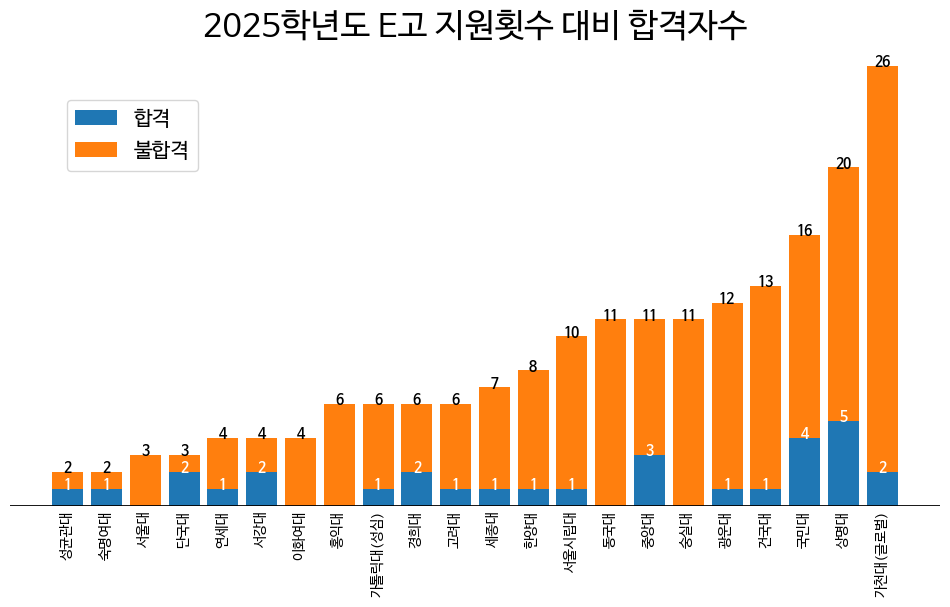

In [ ]:
#4. 서울주요대 합격자 및 불합격자 누적 세로 막대그래프

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 데이터 부르기
path = '/content/drive/MyDrive/python/habbul/'
df = pd.read_excel(f'{path}eunpyeong_2025_habbul.xlsx')

uni = ['서울대', '연세대', '고려대', '서강대', '성균관대', '한양대', '중앙대', '경희대', '한국외대', '서울시립대', '이화여대',
       '건국대', '동국대', '홍익대','숙명여대', '국민대', '숭실대', '세종대', '단국대', '광운대', '명지대', '상명대', '가천대(글로벌)', '가톨릭대(성심)']


# create a new DataFrame containing the number of applications and acceptance for each university and sort it in ascending order by number of applications
num_applications = []
num_acceptance = []
for u in uni:
    uni_admissions = df[df['대학'] == u]
    num_app = len(uni_admissions)
    num_acc = len(uni_admissions[uni_admissions['최종'] == '합'])
    num_applications.append(num_app)
    num_acceptance.append(num_acc)

admission_df = pd.DataFrame({'대학': uni, '지원건수': num_applications, '합격건수': num_acceptance})


# 빈도가 0인 경우 해당 label을 x축 label에서 제거
admission_df = admission_df[admission_df['지원건수'] != 0]

# 그래프를 오름차순으로 정렬하기
admission_df = admission_df.sort_values('지원건수')


# create a vertical stacked bar plot of the number of applications and acceptance
plt.figure(figsize=(12,6))
plt.bar(x='대학', height='합격건수', data=admission_df, bottom=0, label='합격')
plt.bar(x='대학', height= admission_df['지원건수']- admission_df['합격건수'], data=admission_df, bottom=admission_df['합격건수'],
        label='불합격')


plt.xticks(rotation=90, ha='center')
plt.title('2025학년도 E고 지원횟수 대비 합격자수', fontsize=24)

# add labels on top of the bars for the number of accepted applicants
for i, v in enumerate(admission_df['합격건수']):
    if v > 0:
        plt.text(i, v, str(v), color='white', ha='center', fontweight='bold')  #글자색 white
        #plt.text(i, v, str(v), color='black', ha='center', fontweight='bold') #글자색 black

for a, b in enumerate(admission_df['지원건수']):
    if b > 0:
        plt.text(a, b, str(b), color='black', ha='center', fontweight='bold')

# modify the y-tick range to start from 1 instead of 0
plt.yticks(np.arange(1, 21, 2))

# y축 제거
plt.yticks([])

# remove ticks and spines from the y-axis and top x-axis
plt.tick_params(axis='y', which='both', length=0)  # remove ticks from y-axis
#plt.tick_params(axis='x', which='both', length=0, top=False)  # remove ticks from top x-axis
plt.gca().spines['top'].set_visible(False)  # remove spine from top x-axis
plt.gca().spines['right'].set_visible(False)  # remove spine from right y-axis
plt.gca().spines['left'].set_visible(False)  # remove spine from right y-axis
plt.gca().spines['bottom'].set_visible(False)  # remove spine from right y-axis

# create a horizontal line on the x-axis
plt.axhline(y=0, color='black', linewidth=2)

# move the legend to the right and adjust its position
plt.legend(fontsize = 15, loc='upper left', bbox_to_anchor=(0.05, 0.9))

# X축 눈금(ticks) 제거
plt.tick_params(axis='x', which='both', length=0)
# adjust the spacing of the plot to make room for the legend
#plt.subplots_adjust(right=0.75)



plt.show()

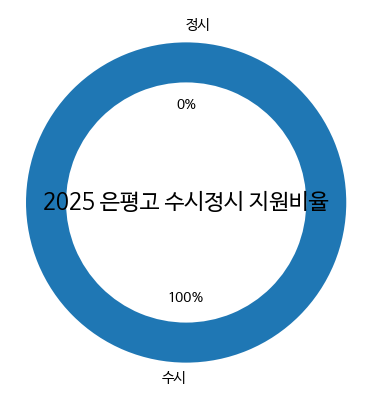

In [ ]:
#5. 수시정시 지원률 도넛차트 그래프

import pandas as pd
import matplotlib.pyplot as plt


##  데이터 부르기
path = '/content/drive/MyDrive/python/habbul/'
df = pd.read_excel(f'{path}eunpyeong_2025_habbul.xlsx')



# 조건에 따라 '지원시기'열의 값 변경
df['지원시기'] = df['지원시기'].replace({'가': '정시', '나': '정시', '다': '정시', '정시1차':'정시',
                                       '수시1차': '수시', '수시2차': '수시', '수시': '수시'})


# '지원시기'별 비율 계산
지원시기_비율 = (df['지원시기'].value_counts(normalize=True) * 100).astype(int)  # 정수로 변환 후 퍼센트로 변환
labels = 지원시기_비율.index


# '최종' 열의 값이 '합'인 경우는 '합격', '불'인 경우는 '불합격'으로 변경
df['최종'] = df['최종'].apply(lambda x: '합격' if x == '합' else '불합격')


# '합격'과 '불합격'별 비율 계산
최종_비율 = (df['최종'].value_counts(normalize=True) * 100).astype(int)  # 정수로 변환 후 퍼센트로 변환


# '지원시기' 도넛 차트
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.pie(지원시기_비율, labels=labels, autopct='%1.0f%%', startangle=90, colors=plt.cm.tab20.colors, wedgeprops=dict(width=0.25))




# 제목 추가
plt.text(0, 0, '2025 은평고 수시정시 지원비율', fontsize=16, ha='center', va='center')
plt.axis('equal')  # 동그랗게 만들기


path = '/content/drive/MyDrive/python/eunpyeong/result_habbul/'

plt.show()


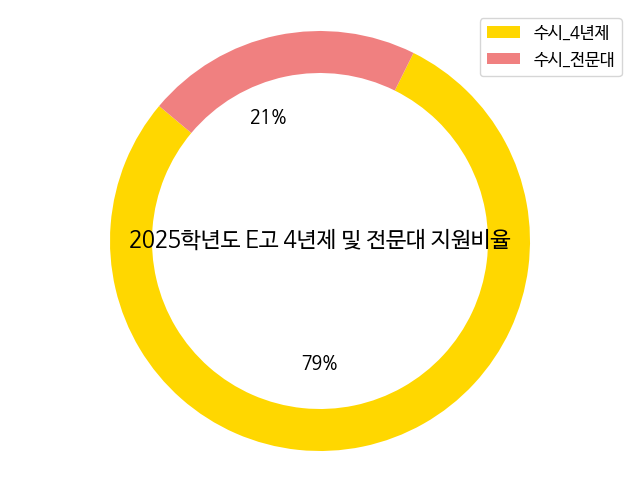

In [ ]:
#6. 수시정시 4년제/전문대 구분 지원비율 도넛차트

import pandas as pd
import matplotlib.pyplot as plt


##  데이터 부르기
path = '/content/drive/MyDrive/python/habbul/'
df = pd.read_excel(f'{path}eunpyeong_2025_habbul.xlsx')


# 조건에 따라 '지원시기'열의 값 변경
df['지원시기'] = df['지원시기'].replace({'가': '정시', '나': '정시', '다': '정시', '정시1차':'정시',
                                       '수시1차': '수시_전문대', '수시2차': '수시_전문대', '수시': '수시_4년제'})


# 변경된 '지원시기'열의 값으로 groupby하여 빈도 계산
frequency = df.groupby('지원시기').size().reset_index(name='빈도')


# 각 항목별 비율 계산하여 '비율' 열에 저장
frequency['비율(%)'] = (frequency['빈도'] / frequency['빈도'].sum() * 100).astype(int)


# 데이터프레임에서 '지원시기'와 '빈도' 열 추출
labels = frequency['지원시기']
sizes = frequency['빈도']
colors = ['gold', 'lightcoral', 'lightskyblue']
explode = (0.02, 0, 0)  # 각 조각이 도넛에서 얼마나 떨어져 있는지 설정



# Ensure that explode has the same length as sizes
if len(explode) != len(sizes):
    explode = tuple(0 for _ in sizes)  # Set all explode values to 0 if lengths don't match


# 도넛 차트 생성
plt.figure(figsize=(8, 6))
wedges, texts, autotexts = plt.pie(sizes, explode=explode, colors=colors, autopct='%1.1f%%', startangle=140, wedgeprops=dict(width=0.2))
plt.axis('equal')  # 동그랗게 만들기


# labels를 도넛 차트 위에 표시
plt.legend(wedges, labels, loc="best", fontsize=12)


# 비율(%)을 정수로 표시
for autotext in autotexts:
    autotext.set_text('{:.0f}%'.format(float(autotext.get_text().strip('%'))))



# 비율(%)의 글자 크기 확대 및 위치 조정
for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_position((autotext.get_position()[0] - 0.21, autotext.get_position()[1] ))
    autotext.set_horizontalalignment('left')


# '수시_4년제'에 해당하는 텍스트 위치 변경
for i, label in enumerate(labels):
    if label == '수시':
        autotexts[i].set_position((autotexts[i].get_position()[0], autotexts[i].get_position()[1] ))  # 수동으로 위치 조정

# 제목 추가
plt.text(0, 0, '2025학년도 E고 4년제 및 전문대 지원비율', fontsize=16, ha='center', va='center')



plt.show()

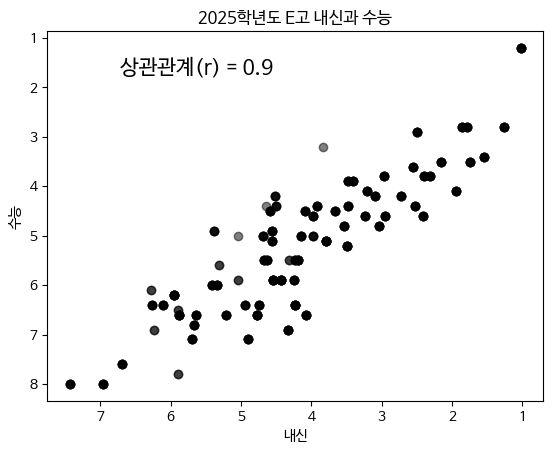

In [ ]:
#7. 내신과 수능과 상관관계A: 산포도

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Drop rows with any NaN values in '전과목' or '등급수능' columns
df = df.dropna(subset=['전과목', '등급수능'])


# Extract '전과목' and '등급수능' columns
x = df['전과목'].values
y = df['등급수능'].values


# Calculate the correlation coefficient
corr_coef = np.corrcoef(x, y)[0, 1]


# Create the scatter plot
plt.scatter(x, y, alpha=0.5,  c='black')
plt.title('2025학년도 E고 내신과 수능')
plt.xlabel('내신')
plt.ylabel('수능')

# Add the correlation coefficient to the plot
plt.text(0.3, 0.9, f'상관관계(r) = {corr_coef:.1f}',
         horizontalalignment='center', verticalalignment='center',
         transform=plt.gca().transAxes, fontsize=15)

# Reverse the x-axis and y-axis
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()



plt.show()

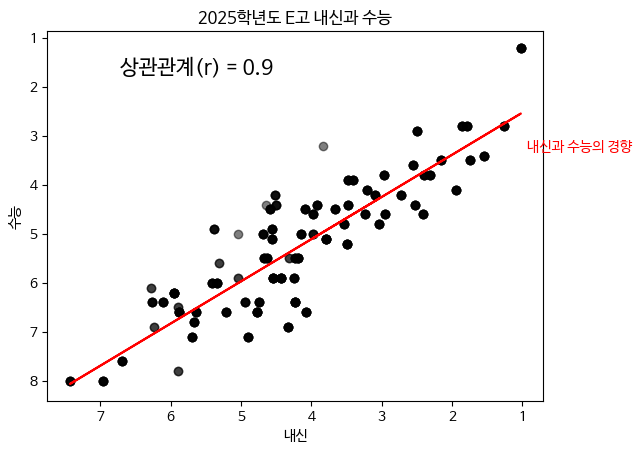

In [ ]:
#7-1. 내신과 수능과 상관관계B: 산포도에 추세선(회귀선) 표시


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Drop rows with any NaN values in '전과목' or '등급수능' columns
df = df.dropna(subset=['전과목', '등급수능'])

# Extract '전과목' and '등급수능' columns
x = df['전과목'].values
y = df['등급수능'].values

# Calculate the correlation coefficient
corr_coef = np.corrcoef(x, y)[0, 1]

# Create the scatter plot
plt.scatter(x, y, alpha=0.5, c='black')
plt.title('2025학년도 E고 내신과 수능')
plt.xlabel('내신')
plt.ylabel('수능')

# Add the correlation coefficient to the plot
plt.text(0.3, 0.9, f'상관관계(r) = {corr_coef:.1f}',
         horizontalalignment='center', verticalalignment='center',
         transform=plt.gca().transAxes, fontsize=15)

# Reverse the x-axis and y-axis
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

# Calculate linear regression line
m, b = np.polyfit(x, y, 1)
# Add linear regression line to scatter plot
plt.plot(x, m*x + b, color='red')


# Add text for the regression line
plt.text(np.median(x)- 3.3, m*np.median(x) + b - 2, '내신과 수능의 경향', color='red')


# 저장 경로 설정
path1 = '/content/drive/MyDrive/python/eunpyeong/result_png/'
path2 = '/content/drive/MyDrive/python/eunpyeong/result_pdf/'

# 그래프 저장
plt.savefig(f'{path1}pass_2025_은평고_내신수능산포도_회귀선.png')
plt.savefig(f'{path2}pass_2025_은평고_내신수능산포도_회귀선.pdf')

plt.show()

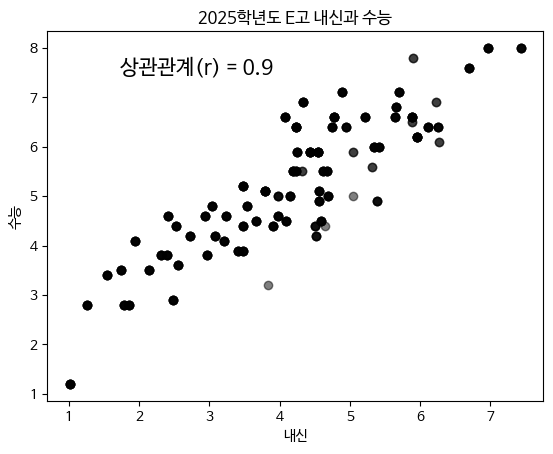

In [ ]:
#보조자료. 내신과 수능과 상관관계B: 역방향 산포도

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Drop rows with any NaN values in '전과목' or '등급수능' columns
df = df.dropna(subset=['전과목', '등급수능'])


# Extract '전과목' and '등급수능' columns
x = df['전과목'].values
y = df['등급수능'].values


# Calculate the correlation coefficient
corr_coef = np.corrcoef(x, y)[0, 1]


# Create the scatter plot
plt.scatter(x, y, alpha=0.5,  c='black')
plt.title('2025학년도 E고 내신과 수능')
plt.xlabel('내신')
plt.ylabel('수능')

# Add the correlation coefficient to the plot
plt.text(0.3, 0.9, f'상관관계(r) = {corr_coef:.1f}',
         horizontalalignment='center', verticalalignment='center',
         transform=plt.gca().transAxes, fontsize=15)

# Reverse the x-axis and y-axis
#plt.gca().invert_xaxis()
#plt.gca().invert_yaxis()


#그래프 저장
path = '/content/drive/MyDrive/python/eunpyeong/result_habbul/'
plt.savefig(f'{path}pass_2025_은평고_내신수능상관계수_reverse.png')
plt.savefig(f'{path}pass_2025_은평고_내신수능상관계수__reverse.pdf')

plt.show()

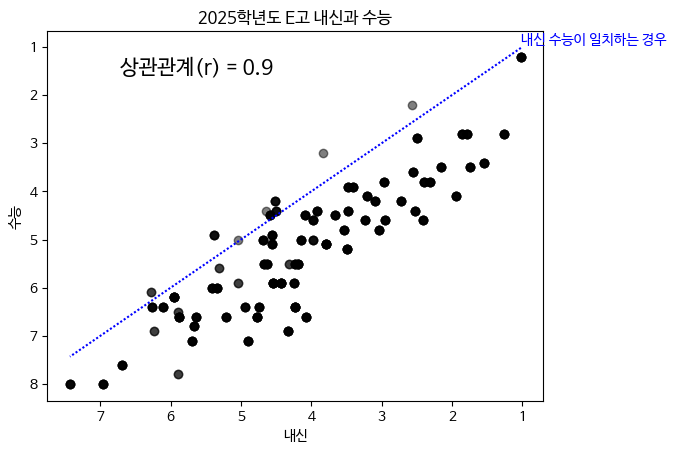

In [ ]:
#7-2. 내신과 수능과 상관관계D: 산포도에 1:1대응 직선

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Drop rows with any NaN values in '전과목' or '등급수능' columns
df = df.dropna(subset=['전과목', '등급수능'])

# Extract '전과목' and '등급수능' columns
x = df['전과목'].values
y = df['등급수능'].values

# Calculate the correlation coefficient
corr_coef = np.corrcoef(x, y)[0, 1]

# Create the scatter plot
plt.scatter(x, y, alpha=0.5, c='black')
plt.title('2025학년도 E고 내신과 수능')
plt.xlabel('내신')
plt.ylabel('수능')

# Add the correlation coefficient to the plot
plt.text(0.3, 0.9, f'상관관계(r) = {corr_coef:.1f}',
         horizontalalignment='center', verticalalignment='center',
         transform=plt.gca().transAxes, fontsize=15)

# Reverse the x-axis and y-axis
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

# Calculate linear regression line
#m, b = np.polyfit(x, y, 1)
# Add linear regression line to scatter plot
#plt.plot(x, m*x + b, color='red')


# Add text for the regression line
#plt.text(np.median(x)- 3.3, m*np.median(x) + b - 2, '내신 수능 추세선', color='red')

# Add a 1:1 line
plt.plot([min(x), max(x)], [min(x), max(x)], color='blue', linestyle='--', dashes=[1, 1]) # 1:1 대응 직선 추가



# Add text for the 1:1 line
plt.text(min(x), min(x), '내신 수능이 일치하는 경우', color='blue', verticalalignment='bottom')

# 저장 경로 설정
path1 = '/content/drive/MyDrive/python/eunpyeong/result_png/'
path2 = '/content/drive/MyDrive/python/eunpyeong/result_pdf/'

# 그래프 저장
plt.savefig(f'{path1}pass_2025_은평고_내신수능산포도_회귀선_일대일대응선.png')
plt.savefig(f'{path2}pass_2025_은평고_내신수능산포도_회귀선_일대일대응선.pdf')

plt.show()


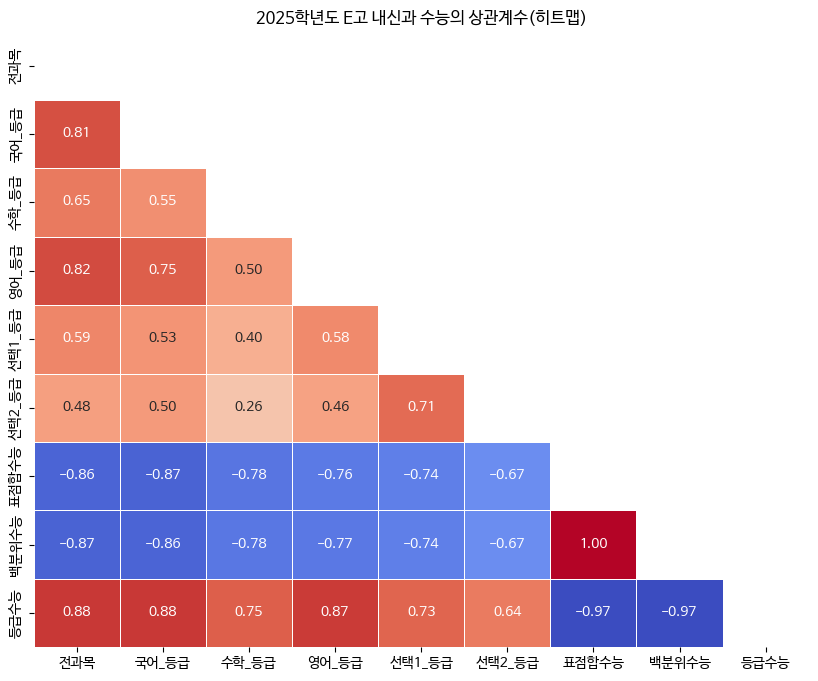

In [ ]:
#8. 내신과 수능과 상관관계(히트맵)


import seaborn as sns

#일부 항목추출
df_heatmap = df[['전과목', '국어_등급', '수학_등급', '영어_등급', '선택1_등급', '선택2_등급', '표점합수능',  '백분위수능',  '등급수능']]


# 상관계수 계산
corr = df_heatmap.corr()



# 대각행렬 오른쪽 부분을 마스킹 (대각선을 포함한 오른쪽 상단 부분을 제외)
mask = np.triu(np.ones_like(corr, dtype=bool))


# 히트맵 그리기
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, mask=mask, cbar=False)
plt.title('2025학년도 E고 내신과 수능의 상관계수(히트맵)')

path = '/content/drive/MyDrive/python/eunpyeong/result_habbul/'
#plt.savefig(f'{path}pass_2025_은평고_히트맵상관계수.png')
#plt.savefig(f'{path}pass_2025_은평고_히트맵상관계수.pdf')

plt.show()

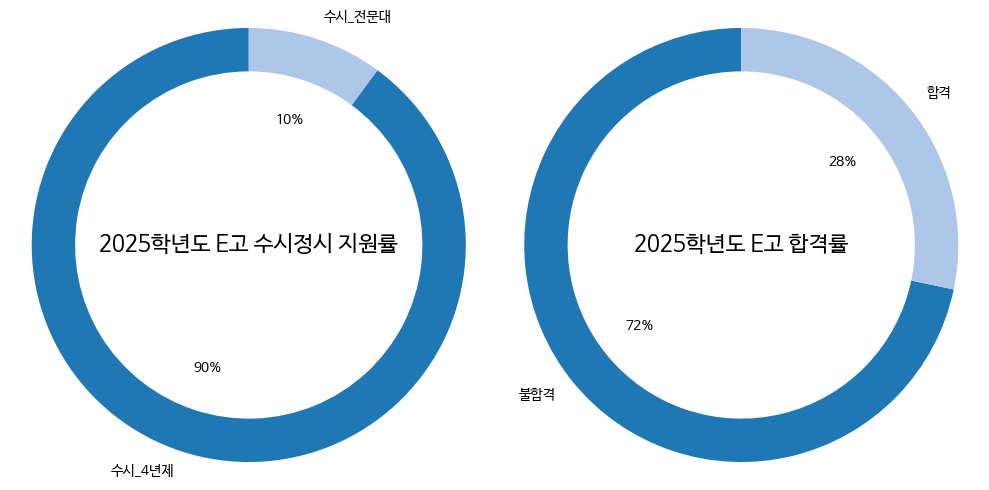

In [ ]:
#9. 수시정시 지원률과 합격률 도넛차트

import pandas as pd
import matplotlib.pyplot as plt



# 조건에 따라 '지원시기'열의 값 변경
df['지원시기'] = df['지원시기'].replace({'가': '정시', '나': '정시', '다': '정시', '정시1차':'정시',
                                       '수시1차': '수시_전문대', '수시2차': '수시_전문대', '수시': '수시_4년제'})


# '지원시기'별 비율 계산
지원시기_비율 = (df['지원시기'].value_counts(normalize=True) * 100).astype(int)  # 정수로 변환 후 퍼센트로 변환
labels = 지원시기_비율.index


# '최종' 열의 값이 '합'인 경우는 '합격', '불'인 경우는 '불합격'으로 변경
#df['최종'] = df['최종'].apply(lambda x: '합격' if x == '합' else '불합격')


# '최종' 열의 값을 '합격', '불합격'으로 직접 변경
df['최종'] = df['최종'].replace({'합': '합격', '불': '불합격'})


# '합격'과 '불합격'별 비율 계산
최종_비율 = (df['최종'].value_counts(normalize=True) * 100).astype(int)  # 정수로 변환 후 퍼센트로 변환


# '지원시기' 도넛 차트
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.pie(지원시기_비율, labels=labels, autopct='%1.0f%%', startangle=90, colors=plt.cm.tab20.colors, wedgeprops=dict(width=0.2))
# 제목 추가
plt.text(0, 0, '2025학년도 E고 수시정시 지원률', fontsize=16, ha='center', va='center')
plt.axis('equal')  # 동그랗게 만들기



# 지원건수 대비 합격률 도넛 차트
plt.subplot(1, 2, 2)
plt.pie(최종_비율, labels=최종_비율.index, autopct='%1.0f%%', startangle=90, colors=plt.cm.tab20.colors, wedgeprops=dict(width=0.2))
plt.text(0, 0, '2025학년도 E고 합격률', fontsize=16, ha='center', va='center')
plt.axis('equal')  # 동그랗게 만들기

plt.tight_layout()  # subplot 간 간격 조절


plt.show()

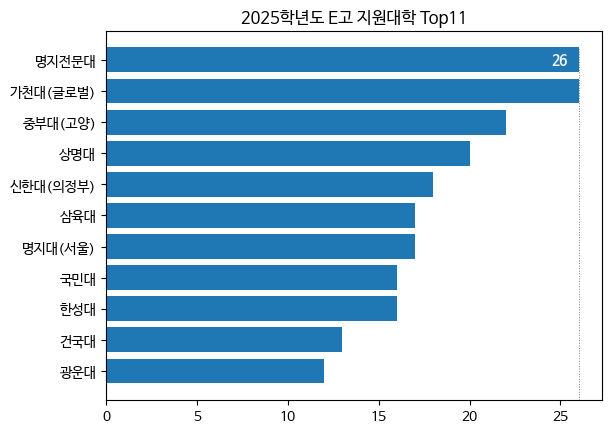

In [ ]:
#10. 지원대학 막대그래프

import pandas as pd
import matplotlib.pyplot as plt


# 데이터 불러오기
path = '/content/drive/MyDrive/python/habbul/'
df = pd.read_excel(f'{path}eunpyeong_2025_habbul.xlsx')

# Filter the rows based on the frequency of the "대학" column
freq = df['대학'].value_counts()
freq = freq[freq >= 12]

# 대학수
freq_num = len(freq)

# Create a horizontal bar plot with descending order
freq_sorted = freq.sort_values()
plt.barh(freq_sorted.index, freq_sorted)



# Draw a dotted vertical line only from the X-axis tick with maximum value of the plot
max_value = max(freq_sorted)
plt.axvline(max_value, linestyle=':', color='gray', linewidth=0.7, ymax=0.95)  # 아래쪽 x축까지 선이 도달하도록 ymax 설정



# Annotate the maximum value on the plot
plt.text(max_value - 1.5, len(freq_sorted) - 1, f'{max_value}', color='white', fontsize=10, va='center', fontweight='bold')



# Save the plot in png and pdf formats
path1 = '/content/drive/MyDrive/python/eunpyeong/result_habbul/'

plt.title(f"2025학년도 E고 지원대학 Top{freq_num}")
#plt.savefig(f'{path1}2025uni_preferred.png', dpi=300, bbox_inches='tight')
#plt.savefig(f'{path1}2025uni_preferred.pdf', bbox_inches='tight')
plt.show()

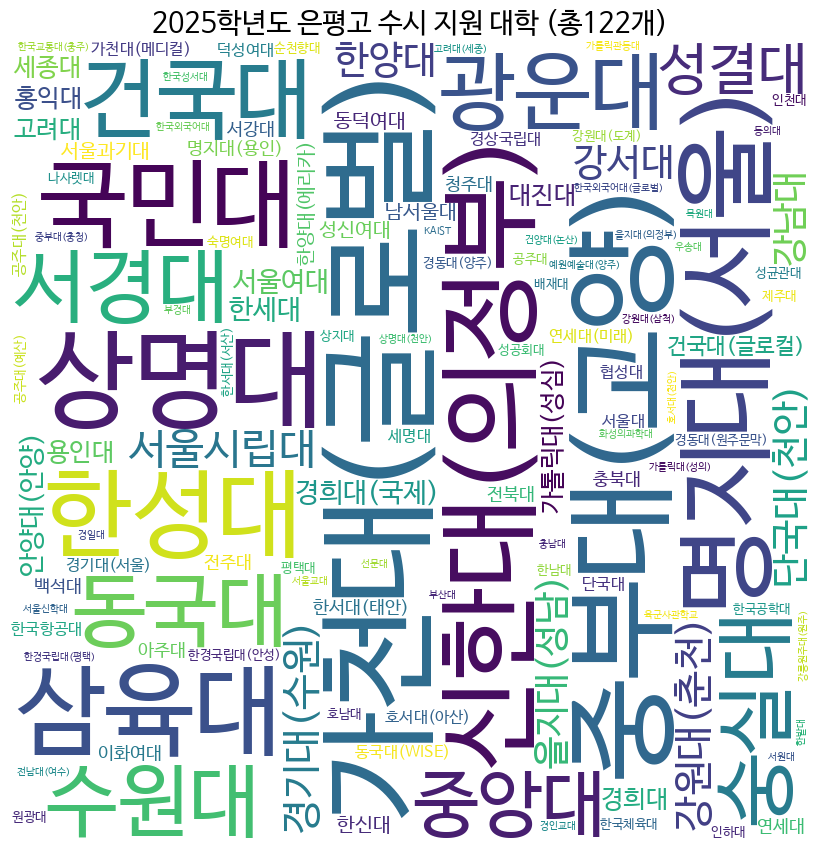

In [ ]:
#11.지원대학 워드클라우드(wordcloud)

import random
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import datetime

# Get the current year
current_year = datetime.datetime.now().year


# Assuming the academic year starts this year and continues into the next year
academic_year = f"{current_year}학년도"


#지원시기: 수시
df_apply = df[df.지원시기  == '수시']



#중복제외한 대학수
df_dup = df_apply.drop_duplicates('대학')
df_freq = len(df_dup['대학'])



#결과를 하나로 고정
random.seed(42)  # set the random seed



wordcloud = WordCloud(font_path='NanumBarunGothic', width=800, height=800, background_color='white', min_font_size=10).generate_from_frequencies(df_apply['대학'].value_counts())


fig = plt.figure(figsize=(8, 8))
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)


# Now update the title string to include the current academic year
plt.title(f"{academic_year} 은평고 수시 지원 대학 (총{df_freq}개)", fontsize=20)

path = '/content/drive/MyDrive/python/eunpyeong/result_wordcloud/'
pdf_path = f'{path}2025학년도_은평고_wordcloud.pdf'
plt.savefig(pdf_path, dpi=300, bbox_inches='tight', pad_inches=0)

wordcloud.to_file(f'{path}2025학년도_은평고_wordcloud.png')

plt.show()

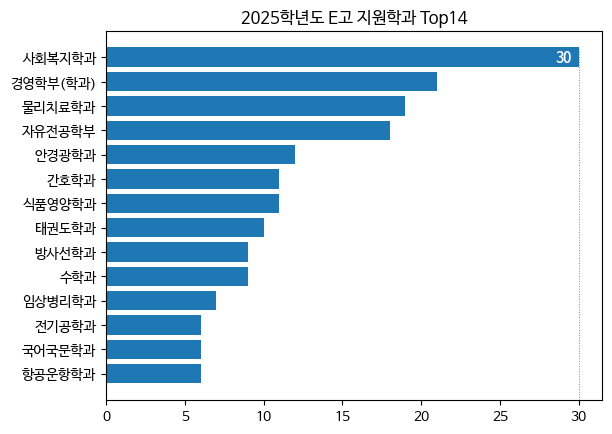

In [ ]:
#12. 지원학과 막대그래프(가로)

import pandas as pd
import matplotlib.pyplot as plt

# 데이터 불러오기
path = '/content/drive/MyDrive/python/habbul/'
df = pd.read_excel(f'{path}eunpyeong_2025_habbul.xlsx')


# '모집단위' 열에서 '경영학과'와 '경영학부'를 '경영학부(학과)'로 합산
df['모집단위'] = df['모집단위'].replace({'경영학과': '경영학부(학과)', '경영학부': '경영학부(학과)'})

# '모집단위' 열에서 '컴퓨터관련학과' 합산
df['모집단위'] = df['모집단위'].replace({'컴퓨터소프트웨어학과': '컴퓨터과학과', '소프트웨어학과': '컴퓨터과학과',  '컴퓨터공학과': '컴퓨터과학과'})


# '모집단위' 열에서 '국어교육문학' 합산
df['모집단위'] = df['모집단위'].replace({'국어국문문예창작학부': '국어교육문학전공', '국어교육과': '국어교육문학전공'})


# '모집단위' 열에서 '사회복지학과' 합산
df['모집단위'] = df['모집단위'].replace({'사회복지과': '사회복지학과'})


# '모집단위' 열에서 '물리치료과' 합산
df['모집단위'] = df['모집단위'].replace({'물리치료과': '물리치료학과'})



# '모집단위' 열에서 '컴퓨터관련학과' 합산
df['모집단위'] = df['모집단위'].replace({'자유전공': '자유전공학부', '자율설계전공학부': '자유전공학부'})


# Filter the rows based on the frequency of the "대학" column
freq = df['모집단위'].value_counts()
freq = freq[freq >= 6]

# 대학수
freq_num = len(freq)

# Create a horizontal bar plot with descending order
freq_sorted = freq.sort_values()
plt.barh(freq_sorted.index, freq_sorted)



# Draw a dotted vertical line only from the X-axis tick with maximum value of the plot
max_value = max(freq_sorted)
plt.axvline(max_value, linestyle=':', color='gray', linewidth=0.7, ymax=0.95)  # 아래쪽 x축까지 선이 도달하도록 ymax 설정



# Annotate the maximum value on the plot
plt.text(max_value - 1.5, len(freq_sorted) - 1, f'{max_value}', color='white', fontsize=10, va='center', fontweight='bold')



# Save the plot in png and pdf formats
path1 = '/content/drive/MyDrive/python/eunpyeong/result_habbul/'

plt.title(f"2025학년도 E고 지원학과 Top{freq_num}")
plt.savefig(f'{path1}2025haggwa_preferred.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{path1}2025haggwa_preferred.pdf', bbox_inches='tight')
plt.show()

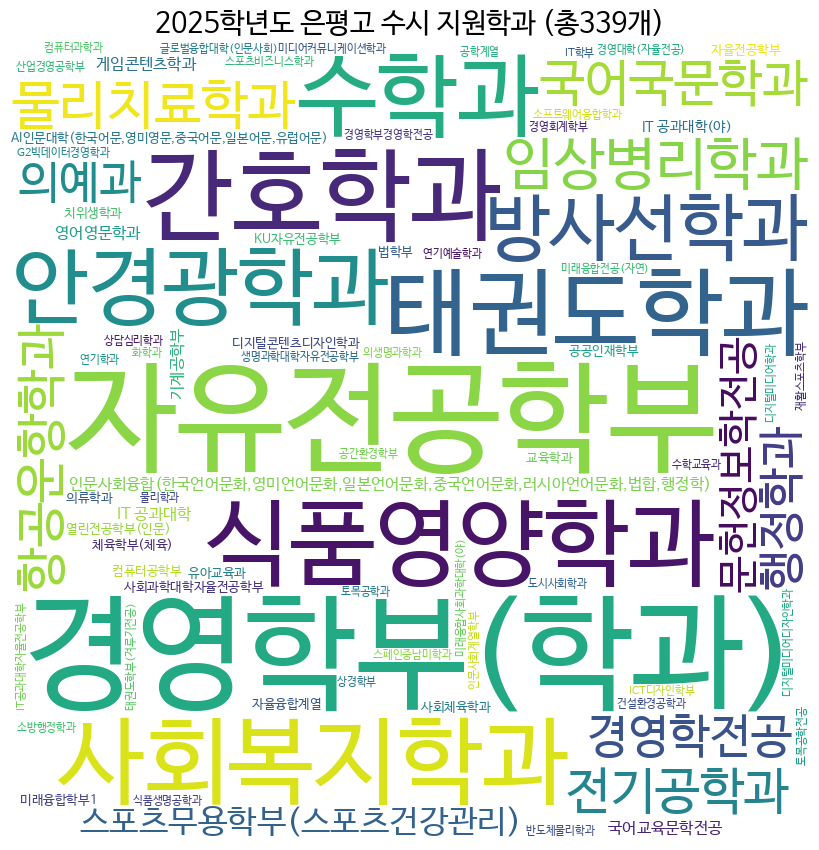

In [ ]:
#13. 지원학과 워드클라우드(wordcloud)

import random
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import datetime

# Get the current year
current_year = datetime.datetime.now().year


# Assuming the academic year starts this year and continues into the next year
academic_year = f"{current_year}학년도"


# '모집단위' 열에서 '경영학과'와 '경영학부'를 '경영학부(학과)'로 합산
df['모집단위'] = df['모집단위'].replace({'경영학과': '경영학부(학과)', '경영학부': '경영학부(학과)'})



# '모집단위' 열에서 '컴퓨터관련학과' 합산
df['모집단위'] = df['모집단위'].replace({'컴퓨터소프트웨어학과': '컴퓨터과학과', '소프트웨어학과': '컴퓨터과학과',  '컴퓨터공학과': '컴퓨터과학과'})



# '모집단위' 열에서 '국어교육문학' 합산
df['모집단위'] = df['모집단위'].replace({'국어국문문예창작학부': '국어교육문학전공', '국어교육과': '국어교육문학전공'})


# '모집단위' 열에서 '사회복지학과' 합산
df['모집단위'] = df['모집단위'].replace({'사회복지과': '사회복지학과'})


# '모집단위' 열에서 '물리치료과' 합산
df['모집단위'] = df['모집단위'].replace({'물리치료과': '물리치료학과'})



# '모집단위' 열에서 '컴퓨터관련학과' 합산
df['모집단위'] = df['모집단위'].replace({'자유전공': '자유전공학부', '자율설계전공학부': '자유전공학부'})



#지원시기: 수시
df_apply = df[df.지원시기  == '수시']


#중복제외한 대학수
df_dup = df_apply.drop_duplicates('모집단위')
df_freq = len(df_dup['모집단위'])



#결과를 하나로 고정
random.seed(42)  # set the random seed



wordcloud = WordCloud(font_path='NanumBarunGothic', width=800, height=800, background_color='white', min_font_size=10).generate_from_frequencies(df_apply['모집단위'].value_counts())


fig = plt.figure(figsize=(8, 8))
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)


# Now update the title string to include the current academic year
plt.title(f"{academic_year} 은평고 수시 지원학과 (총{df_freq}개)", fontsize=20)

path = '/content/drive/MyDrive/python/eunpyeong/result_wordcloud/'
pdf_path = f'{path}2025학년도_은평고_wordcloud.pdf'
#plt.savefig(pdf_path, dpi=300, bbox_inches='tight', pad_inches=0)

wordcloud.to_file(f'{path}2025학년도_은평고_지원학과wordcloud.png')

plt.show()

In [ ]:
#14. 학급별 4년제 합격자 명단

from tabulate import tabulate

path = '/content/drive/MyDrive/python/habbul/'
df = pd.read_excel(f'{path}eunpyeong_2025_habbul.xlsx')


#4년제 지원자수(중복포함)
seoul_df_fouryearapply = df[~(df.대학.str.contains("대학교"))]
seoul_df_fouryearapply = len(seoul_df_fouryearapply)

#지역, 최종, ace대학 제외
seoul_df = df[(df.최종 == '합') & ~(df.대학.str.contains("대학교"))]


#4년제 합격건수(중복포함)
seoul_df_freq = len(seoul_df)


#4년제 합격률 = 4년제 합격건수 / 4년제 지원자수
seoul_df_fouryearpass = (seoul_df_freq / seoul_df_fouryearapply) *100
seoul_df_fouryearpass = int(seoul_df_fouryearpass)

#필요한 변수(열)만 불러옴
seoul_df = seoul_df[['지역', '학번', '계열', '이름', '대학', '모집단위', '최종', '전과목', '지원시기', '전형분류']]



#중복제외한 합격자수
seoul_df_person = seoul_df.drop_duplicates('이름')


# tabulate를 사용하여 결과 출력
print(tabulate(seoul_df, headers='keys', tablefmt='plain', showindex=False))
print("********************************************************************")



#합격자수
print("2025학년도  E고 4년제 대학 합격건수는 %d건입니다.(중복합격 포함)" % len(seoul_df))

print("2025학년도  E고 4년제 대학 합격자수는 %d명입니다.(중복제외)" % len(seoul_df_person))


print(f"2025학년도  E고 4년제 대학 합격률은 {seoul_df_fouryearpass}%입니다.(중복포함)")


#데이터 프레임으로 전환
seoul_df_p = pd.DataFrame(seoul_df)


#결과를 엑셀로 저장
path = '/content/drive/MyDrive/python/eunpyeong/result_habbul/'
seoul_df_p.to_excel(excel_writer= f'{path}반별4년제합격자_2025_은평고.xlsx')

In [ ]:
#15. 4년제대 합격자 명단

import pandas as pd
from tabulate import tabulate

path = '/content/drive/MyDrive/python/habbul/'
df = pd.read_excel(f'{path}eunpyeong_2025_habbul.xlsx')



#4년제 지원자수(중복포함)
#seoul_df_fouryearapply = df[~(df.대학.str.contains("대학교"))]
#seoul_df_fouryearapply = len(seoul_df_fouryearapply)


# 지역, 최종, 특정 대학 제외
exclude_universities = ["대학교", "명지전문", "인하공업", "한국폴리텍"]
seoul_df = df[(df.최종 == '합') & ~df.대학.str.contains("|".join(exclude_universities))]



#4년제 합격건수(중복포함)
seoul_df_freq = len(seoul_df)



#필요한 변수(열)만 불러옴
seoul_df = seoul_df[['지역', '학번', '계열', '이름', '대학', '모집단위', '최종', '전과목', '지원시기', '전형분류']]



#중복제외한 합격자수
seoul_df_person = seoul_df.drop_duplicates('이름')
seoul_df_person = len(seoul_df_person)



#졸업생대비 4년제 합격률 = 4년제 합격자 / 졸업생수(147)
numofgraduate = 147
seoul_df_fouryearpass = (seoul_df_person / numofgraduate) *100
seoul_df_fouryearpass = int(seoul_df_fouryearpass)



#합격자수
print("2025학년도  E고 4년제 합격건수는 %d건입니다.(중복합격 포함)" % len(seoul_df))

print(f"2025학년도  E고 4년제 합격자수는 {seoul_df_person}명입니다.(중복제외)")


print(f"2025학년도  E고 4년제 졸업생 대비 합격률은 {seoul_df_fouryearpass}%입니다.(중복포함)")

# tabulate를 사용하여 결과 출력
print(tabulate(seoul_df, headers='keys', tablefmt='plain', showindex=False))
print("********************************************************************")



In [ ]:
#16. 수도권(서울, 경기, 인천) 4년제 합격자 명단

from tabulate import tabulate

path = '/content/drive/MyDrive/python/habbul/'
df = pd.read_excel(f'{path}eunpyeong_2025_habbul.xlsx')

area = ['서울', '경기', '인천']

#4년제 지원자수(중복포함)
seoul_df_fouryearapply = df[~(df.대학.str.contains("대학교"))]
seoul_df_fouryearapply = len(seoul_df_fouryearapply)



# 지역, 최종, 특정 대학 제외
exclude_universities = ["대학교", "명지전문", "인하공업", "한국폴리텍"]
seoul_df = df[(df.최종 == '합') & ~df.대학.str.contains("|".join(exclude_universities))]


seoul_df = seoul_df[seoul_df['지역'].isin(area)]


#4년제 합격건수(중복포함)
seoul_df_freq = len(seoul_df)



#필요한 변수(열)만 불러옴
seoul_df = seoul_df[['지역', '학번', '계열', '이름', '대학', '모집단위', '최종', '전과목', '지원시기', '전형분류']]



#중복제외한 합격자수
seoul_df_person = seoul_df.drop_duplicates('이름')
seoul_df_person = len(seoul_df_person)



#졸업생대비 4년제 합격률 = 4년제 합격자 / 졸업생수(147)
numofgraduate = 147
seoul_df_fouryearpass = (seoul_df_person / numofgraduate) *100
seoul_df_fouryearpass = int(seoul_df_fouryearpass)



#합격자수
print("2025학년도  E고 4년제 수도권대 합격건수는 %d건입니다.(중복합격 포함)" % len(seoul_df))

print(f"2025학년도  E고 4년제 수도권대 합격자수는 {seoul_df_person}명입니다.(중복제외)")


print(f"2025학년도  E고 4년제 수도권대 졸업생 대비 합격률은 {seoul_df_fouryearpass}%입니다.(중복포함)")

# tabulate를 사용하여 결과 출력
print(tabulate(seoul_df, headers='keys', tablefmt='plain', showindex=False))
print("********************************************************************")


#데이터 프레임으로 전환
seoul_df_p = pd.DataFrame(seoul_df)


#결과를 엑셀로 저장
path = '/content/drive/MyDrive/python/eunpyeong/result_habbul/'
seoul_df_p.to_excel(excel_writer= f'{path}수도권합격자명단_2025_은평고.xlsx')

In [ ]:
#17. 전문대 합격자 명단

from tabulate import tabulate

path = '/content/drive/MyDrive/python/habbul/'
df = pd.read_excel(f'{path}eunpyeong_2025_habbul.xlsx')

area = ['서울', '경기', '인천']


# 지역, 최종, 특정 대학 포함
exclude_universities = ["대학교", "명지전문", "인하공업", "한국폴리텍"]
seoul_df = df[(df.최종 == '합') & df.대학.str.contains("|".join(exclude_universities))]



#4년제 합격건수(중복포함)
seoul_df_freq = len(seoul_df)



#필요한 변수(열)만 불러옴
seoul_df = seoul_df[['지역', '학번', '계열', '이름', '대학', '모집단위', '최종', '전과목', '지원시기', '전형분류']]



#중복제외한 합격자수
seoul_df_person = seoul_df.drop_duplicates('이름')
seoul_df_person = len(seoul_df_person)



#졸업생대비 4년제 합격률 = 4년제 합격자 / 졸업생수(147)
numofgraduate = 147
seoul_df_fouryearpass = (seoul_df_person / numofgraduate) *100
seoul_df_fouryearpass = int(seoul_df_fouryearpass)



#합격자수
print("2025학년도  E고 전문대 합격건수는 %d건입니다.(중복합격 포함)" % len(seoul_df))

print(f"2025학년도  E고 전문대 합격자수는 {seoul_df_person}명입니다.(중복제외)")


print(f"2025학년도  E고 전문대 졸업생 대비 합격률은 {seoul_df_fouryearpass}%입니다.(중복포함)")

# tabulate를 사용하여 결과 출력
print(tabulate(seoul_df, headers='keys', tablefmt='plain', showindex=False))
print("********************************************************************")

In [ ]:
#18. 인서울 4년제 합격자 명단


#15. 4년제 합격자 명단

from tabulate import tabulate

path = '/content/drive/MyDrive/python/habbul/'
df = pd.read_excel(f'{path}eunpyeong_2025_habbul.xlsx')

area = ['서울']


# 지역, 최종, 특정 대학 포함
exclude_universities = ["대학교", "명지전문", "인하공업", "한국폴리텍"]
seoul_df = df[(df.최종 == '합') & ~df.대학.str.contains("|".join(exclude_universities))]


#인서울로 제한
seoul_df = seoul_df[seoul_df['지역'].isin(area)]



#4년제 합격건수(중복포함)
seoul_df_freq = len(seoul_df)



#필요한 변수(열)만 불러옴
seoul_df = seoul_df[['지역', '학번', '계열', '이름', '대학', '모집단위', '최종', '전과목', '지원시기', '전형분류']]



#중복제외한 합격자수
seoul_df_person = seoul_df.drop_duplicates('이름')
seoul_df_person = len(seoul_df_person)



#졸업생대비 4년제 합격률 = 4년제 합격자 / 졸업생수(147)
numofgraduate = 147
seoul_df_fouryearpass = (seoul_df_person / numofgraduate) *100
seoul_df_fouryearpass = int(seoul_df_fouryearpass)



#합격자수
print("2025학년도  E고 인서울 4년제 합격건수는 %d건입니다.(중복합격 포함)" % len(seoul_df))

print(f"2025학년도  E고 인서울 4년제 합격자수는 {seoul_df_person}명입니다.(중복제외)")


print(f"2025학년도  E고 인서울 4년제 졸업생 대비 합격률은 {seoul_df_fouryearpass}%입니다.(중복포함)")

# tabulate를 사용하여 결과 출력
print(tabulate(seoul_df, headers='keys', tablefmt='plain', showindex=False))
print("********************************************************************")



In [ ]:
#16. 지방 4년제 합격자 명단

from tabulate import tabulate

path = '/content/drive/MyDrive/python/habbul/'
df = pd.read_excel(f'{path}eunpyeong_2025_habbul.xlsx')

area = ['서울', '경기', '인천']

#4년제 지원자수(중복포함)
local_df_fouryearapply = df[~(df.대학.str.contains("대학교"))]
local_df_fouryearapply = len(local_df_fouryearapply)

#지역, 최종, ace대학 제외
local_df = df[(df.최종 == '합') & ~(df.대학.str.contains("대학교")) & ~(df.대학.str.contains("전문대"))]

local_df = local_df[~local_df['지역'].isin(area)]


#4년제 합격건수(중복포함)
local_df_freq = len(seoul_df)



#필요한 변수(열)만 불러옴
local_df = local_df[['지역', '학번', '계열', '이름', '대학', '모집단위', '최종', '전과목', '지원시기', '전형분류']]



#중복제외한 합격자수
local_df_person = local_df.drop_duplicates('이름')
local_df_person = len(local_df_person)



#졸업생대비 4년제 합격률 = 4년제 합격자 / 졸업생수(147)
numofgraduate = 147
local_df_fouryearpass = (local_df_person / numofgraduate) *100
local_df_fouryearpass = int(local_df_fouryearpass)



#합격자수
print("2025학년도  E고 4년제 지방 합격건수는 %d건입니다.(중복합격 포함)" % len(seoul_df))

print(f"2025학년도  E고 4년제  지방 합격자수는 {local_df_person}명입니다.(중복제외)")


print(f"2025학년도  E고 4년제 지방 졸업생 대비 합격률은 {local_df_fouryearpass}%입니다.(중복포함)")

# tabulate를 사용하여 결과 출력
print(tabulate(local_df, headers='keys', tablefmt='plain', showindex=False))
print("********************************************************************")


#데이터 프레임으로 전환
seoul_df_p = pd.DataFrame(local_df)


In [ ]:
#16. 4년제 합격자 명단A: 선호대학 순

import pandas as pd
from tabulate import tabulate



# 지역, 최종, ace대학 제외
uni4 = df[(df.최종 == '합') & ~(df.대학.str.contains("대학교"))]

# 필요한 변수(열)만 불러옴
uni4 = uni4[['지역', '이름', '대학', '모집단위', '최종', '전과목', '지원시기', '전형분류', '표점합수능', '백분위수능']]


uni4['전과목'] = uni4['전과목'].round(2)

# NaN 값을 '졸업생'으로 변경
uni4['전과목'].fillna('졸업생', inplace=True)


#대구카톨릭대 국어교육과 합격자 제외
uni4 = uni4[~((uni4['대학'] == '대구가톨릭대') & (uni4['모집단위'] == '국어교육과'))].copy()


# 결과를 출력할 순서대로 정렬
output_order = ['서울대', '연세대', '고려대', '서강대', '성균관대', '한양대', '중앙대', '경희대', '한국외대', '서울시립대', '이화여대', '건국대', '동국대', '홍익대', '숙명여대',
                '국민대', '숭실대', '세종대', '서울과기대', '광운대', '명지대', '상명대', '가톨릭대(성심)', '동덕여대', '가천대(글로벌)', '한국예술종합학교', '공군사관학교', '한성대', '서경대', '삼육대',  '성신여대', '서울여대', '덕성여대', '아주대', '인하대', '한양대(에리카)']


uni4 = uni4.sort_values(by=['대학', '모집단위'], key=lambda x: x.map({v: i for i, v in enumerate(output_order)}))

# tabulate를 사용하여 결과 출력
print(tabulate(uni4, headers='keys', tablefmt='plain', showindex=False))
print("********************************************************************")

# 합격자수
print("2025학년도 은평고 대학 합격자수는 %d건입니다.(중복합격 포함)" % len(uni4))

# 데이터 프레임으로 전환
uni4_p = pd.DataFrame(uni4)

# 결과를 엑셀로 저장
path = '/content/drive/MyDrive/python/eunpyeong/result_habbul/'
uni4_p.to_excel(excel_writer=f'{path}선호대학순_2025_은평고_uniorder.xlsx')

In [ ]:
#17. 4년제대 합격자 명단A: 선호대학 순 - 게시용 익명


from tabulate import tabulate

# 지역, 최종, ace대학 제외
uni4 = df[(df.최종 == '합') & ~(df.대학.str.contains("대학교"))]

# 필요한 변수(열)만 불러옴
uni4 = uni4[['이름', '지역', '대학', '모집단위', '최종', '전과목', '전형분류', '전형명', '전형방법']]

uni4['전과목'] = uni4['전과목'].round(2)


# Show first one letter and replace the rest of the letters with an asterisk in '이름' column
uni4['이름'] = uni4['이름'].apply(lambda x: x[:1] + 'O' * (len(x) - 1) if len(x) >= 2 else x)

# 대구카톨릭대 국어교육과 합격자 제외
uni4 = uni4[~((uni4['대학'] == '대구가톨릭대') & (uni4['모집단위'] == '국어교육과'))].copy()

# 결과를 출력할 순서대로 정렬
output_order = ['대구가톨릭대', '서울대', '연세대', '고려대', '서강대', '성균관대', '한양대', '중앙대', '경희대', '한국외대', '서울시립대', '이화여대', '건국대', '동국대', '홍익대', '숙명여대',
                '국민대', '숭실대', '세종대', '서울과기대', '광운대', '명지대', '상명대', '가톨릭대(성심)', '가천대(글로벌)', '동덕여대', '한성대', '서경대', '삼육대',  '성신여대', '서울여대', '덕성여대', '아주대', '인하대', '한양대(에리카)']



#uni4 = uni4.sort_values(by=['대학', '모집단위'], key=lambda x: x.map({v: i for i, v in enumerate(output_order)}))
uni4 = uni4.sort_values(by=['대학'], key=lambda x: x.map({v: i for i, v in enumerate(output_order)}))


# tabulate를 사용하여 결과 출력
print(tabulate(uni4, headers='keys', tablefmt='plain', showindex=False))
print("********************************************************************")

# 합격자수
print("2025학년도 은평고 대학 합격자수는 %d건입니다.(중복포함)" % len(uni4))

# 데이터 프레임으로 전환
uni4_p = pd.DataFrame(uni4)

# 결과를 엑셀로 저장
path = '/content/drive/MyDrive/python/eunpyeong/result_habbul/'
#uni4_p.to_excel(excel_writer=f'{path}합격자익명_2025_은평고_uniorder_anonymous.xlsx')


## 첫글자는 남기고 나머지 글자는 별표표시

uni4['이름'] = uni4['이름'].apply(lambda x: x[:1] + '*' * (len(x) - 1) if len(x) >= 2 else x)

이 코드는 데이터프레임의 '이름' 열에 있는 각각의 값을 수정하는데 사용됩니다. 여기서는 lambda 함수를 사용하여 각 이름을 변경하고 있습니다.

설명을 간단히 하면:

1. uni4['이름'].apply()는 '이름' 열의 각 항목에 함수를 적용하는 메서드입니다.

2. lambda x: x[:1] + '*' * (len(x) - 1) if len(x) >= 2 else x 부분은 람다 함수입니다. 이 함수는 이름의 길이가 2 이상인 경우에만 실행됩니다.

3. x[:1]은 이름의 첫 번째 글자를 가져옵니다.

4. ' * ' * (len(x) - 1)은 첫 번째 글자를 제외한 나머지 글자를 '*'로 바꿉니다. 글자의 길이에서 1을 빼는 이유는 첫 번째 글자는 그대로 두기 위해서입니다.

5. if len(x) >= 2 else x는 이름이 두 글자 이상일 때만 위의 작업을 수행하고, 그렇지 않으면 이름을 그대로 반환합니다.

In [ ]:
#17-2. 게시용 4년제대 합격자 명단C: '지역', '대학', '모집단위', '지원시기', '전형분류'

from tabulate import tabulate


# 지역, 최종, ace대학 제외
uni4 = df[(df.최종 == '합') & ~(df.대학.str.contains("대학교"))]



# '지원시기' 열의 값이 '가', '나', '다'일 경우 '정시'로 변경
uni4.loc[uni4['지원시기'].isin(['가', '나', '다']), '지원시기'] = '정시'


# 필요한 변수(열)만 불러옴
uni4 = uni4[['지역', '대학', '모집단위', '지원시기', '전형분류']]



#대구카톨릭대 국어교육과 합격자 제외
uni4 = uni4[~((uni4['대학'] == '대구가톨릭대') & (uni4['모집단위'] == '국어교육과'))].copy()



# 결과를 출력할 순서대로 정렬
output_order = ['서울대',  '연세대', '고려대', '서강대', '성균관대', '한양대', '중앙대', '경희대', '한국외대', '서울시립대', '이화여대', '건국대', '동국대', '홍익대', '숙명여대',
                '국민대', '숭실대', '세종대', '서울과기대', '광운대', '명지대', '상명대', '가톨릭대(성심)', '가천대(글로벌)',
                '한국예술종합학교', '공군사관학교', '한성대', '서경대', '삼육대',  '성신여대', '서울여대', '덕성여대', '아주대', '인하대', '한양대(에리카)']


uni4 = uni4.sort_values(by=['대학', '모집단위'], key=lambda x: x.map({v: i for i, v in enumerate(output_order)}))



# 합격자수
print("2025 E고 4년제대 합격자수는 %d건입니다.(중복합격 포함)" % len(uni4))
print("**********************************************************************")


# tabulate를 사용하여 결과 출력
print(tabulate(uni4, headers='keys', tablefmt='plain', showindex=False))


# 데이터 프레임으로 전환
uni4_p = pd.DataFrame(uni4)

# 결과를 엑셀로 저장
path = '/content/drive/MyDrive/python/eunpyeong/result_habbul/'
uni4_p.to_excel(excel_writer=f'{path}pass_2025_은평고_uniorder_board2.xlsx')

In [ ]:
#21. 영어 등급별 인원

mi = int(input("궁금한 영어 수능등급:"))
df_interval = df[(df.영어_등급 == mi)]
df_interval[['학번', '영어_등급']]

df_interval_unique = df_interval['학번'].unique().size
print("영어 수능등급 {}명".format(df_interval_unique))

궁금한 영어 수능등급:1
영어 수능등급 6명


In [ ]:
#22. 학교 수능 백분위평균

# '학번' 열에서 '380'이 들어있지 않은 행 추출: 재수생들 제외
df_filtered = df[~df['학번'].astype(str).str.contains('380')]


df_standard = df_filtered.dropna(subset = ['백분위수능'])


s_mean = df_standard['백분위수능'].mean().round(0)
print(f"2025학년도 E고 수능 백분위점수는 {int(s_mean)}%입니다.")  # 소수점 첫째 자리에서 반올림

In [ ]:
#23. 학교 전체 수능 등급평균


# '학번' 열에서 '380'이 들어있지 않은 행 추출: 재수생들 제외
df_filtered = df[~df['학번'].astype(str).str.contains('380')]


df_standard = df_filtered.dropna(subset = ['등급수능'])


s_mean = df_standard['등급수능'].mean().round(1)
print(f"2025학년도 E고 수능 등급은 {(s_mean)}입니다.")

In [ ]:
#24. 학교 수능 표점합 평균: '국어_표준점수', '수학_표준점수', '선택1_표준점수', '선택2_표준점수'의 열의 값이 모두 1이상인 행의 값을 합산

total_standard_scores = df_filtered[(df_filtered['국어_표준점수'] >= 1) &
                                    (df_filtered['수학_표준점수'] >= 1) &
                                    (df_filtered['선택1_표준점수'] >= 1) &
                                    (df_filtered['선택2_표준점수'] >= 1)].sum(numeric_only=True)

# '표점합수능' 열의 유효값들의 합산을 해당 빈도로 나누어 평균계산
valid_scores_count = df_standard['표점합수능'].count()
total_valid_scores = df_standard['표점합수능'].sum()
average_score = total_valid_scores / valid_scores_count

# 결과 출력
print(f"2025학년도 E고 수능 표점합점수는 {average_score:.0f}점입니다.")

In [ ]:
#24-1. 이름으로 학생의 내신과 석차를 확인: 아름다운 코드 A

# Get input name
name = input("이름:")

# Filter DataFrame to only include rows with the input name
df_filtered = df[df['이름'] == name]

# 학생의 내신
df_filtered_nesin = df_filtered['전과목'].iloc[0].round(1)


# Calculate rank
# 해당 학생보다 내신 성적이 낮은 학생들의 수
lower_scores = df[df['전과목'] < df_filtered_nesin]['이름'].nunique()

# 동일한 내신 성적을 가진 학생들의 수
equal_scores = df[df['전과목'] == df_filtered_nesin]['이름'].nunique() - 1

# 최종 석차 계산
rank = lower_scores + equal_scores + 1

# Print the result
print("********************************************")
print(f"{name}의 내신은 {df_filtered_nesin}등급이고 석차는 {rank}등입니다.")


In [ ]:
#보조: 이름으로 해당 학생의 전체 석차를 확인: 아름다운 코드 B - 단순한 코드

# Get input name
name = input("이름:")

# Filter DataFrame to only include rows with the input name
df_filtered = df[df['이름'] == name]

# Calculate rank of first row in filtered DataFrame
rank = df[df.전과목 < df_filtered.전과목.iloc[0]]
rank = rank.groupby('이름')['전과목'].nunique().sum() + 1

# Print the result
print(f"{name}의 '전과목' 등수는 {rank}등 입니다.")

In [ ]:
#25. 특정 수능 백분위점수 구간의 내신과 수능백분위의 상관관계

import pandas as pd
import numpy as np
from scipy.stats import pearsonr


#특정 백분위 구간의 점수별 빈도(ex: 80~85%사이의 빈도수)
mi = int(input("이상:"))
mx = int(input("미만:"))


# mx이상 mi이하 조건을 충족하는 객체 만들기
df_interval = df[(df.백분위수능 >= mi) & (df.백분위수능 < mx)]

#중복학생을 제외하고 1개만 남김
#df_interval = df_interval.drop_duplicates('이름')

df_interval_name = df_interval[['학번', '이름', '백분위수능', '전과목']].copy()


# 상관계수 및 p-값 계산
corr, p_value = pearsonr(df_interval_name['전과목'], df_interval_name['백분위수능'])
r_squared = corr ** 2

# 결과 출력
print()
print(f"{mi}이상 {mx}이하 수능백분위와 내신의 상관계수: {corr:.2f}")
print(f"p-값: {p_value:.2f}")
print(f"설명력: {r_squared:.2f}")

수능의 이론적 평균
1. 백분위 : 50%
2. 표준점수: 300점 - 국어(100) + 수학(100) + 탐구1(50) + 탐구2(50)
3. 수능등급: 5등급 - 9등급 중 중간값(median)

In [ ]:
#30. 수능이 내신보다 더 잘 나온 학생수와 비율

# Filter the DataFrame
filtered_df = df[df['전과목'] > df['등급수능']]
filtered_df = filtered_df.drop_duplicates(subset='이름')


# Round the '전과목' column to two decimal places
filtered_df['전과목'] = filtered_df['전과목'].apply(lambda x: round(x, 1))

filtered_df_total = df.drop_duplicates(subset='이름')
filtered_df_num = len(filtered_df_total)
filtered_df_num_div = (len(filtered_df) / filtered_df_num)*100
filtered_df_num_div = round(filtered_df_num_div, 0)


# Print the filtered DataFrame
print(filtered_df[['이름', '전과목', '등급수능']])
print("-----------------------------------------------------")
print(f'E고 2025학년도 고3의 수능이 내신보다 높게 나온 학생 {len(filtered_df)}명이고 비율은 {int(filtered_df_num_div)}%입니다.')

In [ ]:
#31. 서울주요대(14개) 학생별 지원결과

import os
import pandas as pd

uni = ['서울대', '연세대', '고려대', '서강대', '성균관대', '한양대', '중앙대', '경희대', '한국외대', '서울시립대', '이화여대', '건국대', '동국대', '홍익대']

# 'uni' 리스트에 해당하는 대학에 지원한 학생들만 필터링
df_filtered = df[df['대학'].isin(uni)]

# '이름'별로 '최종' 열의 합계 계산 ('합'이라는 값이 있으면 1로 계산)
df_filtered['합격건수'] = df_filtered['최종'].apply(lambda x: 1 if x == '합' else 0)
df_filtered['합격건수'] = df_filtered.groupby('이름')['합격건수'].transform('sum').copy()

# 중복 제거
df_unique = df_filtered.drop_duplicates(subset=['이름'])

# 학생별로 결과 출력
for index, row in df_unique.iterrows():
    print(f"\n학생 이름: {row['이름']}, 합격건수: {row['합격건수']}")
    print()
    df_student = df_filtered[df_filtered['이름'] == row['이름']]
    print(df_student[['대학', '모집단위', '최종', '전과목', '전형분류']].to_string(index=False))
    print()
    print("------------------------------------------------------------------")


# 결과를 엑셀 파일로 저장
path = '/content/drive/MyDrive/python/eunpyeong/result_excel/'
os.makedirs(path, exist_ok=True)  # 경로가 없으면 생성

with pd.ExcelWriter(os.path.join(path, '서울14개대_학생지원결과.xlsx')) as writer:
    for index, row in df_unique.iterrows():
        df_student = df_filtered[df_filtered['이름'] == row['이름']]
        df_student[['대학', '모집단위', '최종', '전과목', '전형분류']].to_excel(writer, sheet_name=row['이름'], index=False)

In [ ]:
#32. 영어 1등급 비율계산A: 중복고려하지 않고 전체 1등급학생수를 영어등급학생수로 나눈 비율

df_english1_ratio = (df['영어_등급'] == 1.0).sum() / len(df['영어_등급'])*100
df_english1_ratio_int = int(df_english1_ratio.round(0))
print(f'영어1등급 {df_english1_ratio_int}%')

영어1등급 8%


In [ ]:
#32-1. 영어 1등급 비율계산법B: 중복제외한 응시자수
df_name_uniq = df.drop_duplicates('이름')
df_name_uniq_count = len(df_name_uniq)


#중복 제외한 영어1등급 학생수
df_name_uniq_eng = df_name_uniq[df_name_uniq['영어_등급'] == 1.0 ]
df_name_uniq_eng = len(df_name_uniq_eng)

df_eng_pct = (df_name_uniq_eng / df_name_uniq_count) * 100
df_eng_pct = int(round(df_eng_pct, 0))



print(f'영어 1등급 비율은 {df_eng_pct}%입니다.')

In [ ]:
#33. 수시 영어1등급 학생명단 및 학생수

#라이브러리 불러오기
from tabulate import tabulate

#수시
df_susi = df[df['지원시기'] == '수시']

#1등급 filter
df_susi_english1 = df_susi[df_susi['영어_등급'] == 1.0]


#이름 중복자 제외
df_susi_english1 = df_susi_english1.drop_duplicates('이름')


#백분위수능를 소수점 첫째자리까지 표시
df_susi_english1['백분위수능'] = df_susi_english1['백분위수능'].round(1)


#필요한 열
df_susi_english1 = df_susi_english1[['이름', '영어_등급', '전과목', '백분위수능']]


# Define the table headers
table_headers = ['학번', '이름', '영어_등급', '전과목', '백분위수능']

#영어1등급 받은 학생수
df_susi_english1_num = len(df_susi_english1)

# Create the formatted table using tabulate
table_string = tabulate(df_susi_english1, headers=table_headers, tablefmt='plain')


#출력
print(f'영어1등급 학생은 {df_susi_english1_num}명입니다.')
print()
print(table_string)

In [ ]:
#34. 특정학과별(모집단위) 지원횟수, 합격횟수, 불합격횟수, 합격률

import pandas as pd
from tabulate import tabulate


# 모집단위 입력 받기
uni = input("모집단위: ")

# 모집단위와 '최종' 열이 '합' 또는 '불'인 행 필터링
mask = df['모집단위'].notna() & df['모집단위'].str.contains(uni, na=False)
df_filtered = df[mask].copy()

# '합'과 '불' 빈도 계산
count_total = len(df_filtered)
count_pass = len(df_filtered[df_filtered['최종'].str.contains('합', na=False)])
count_fail = len(df_filtered[df_filtered['최종'].str.contains('불', na=False)]) + len(df_filtered[df_filtered['최종'].isna()])

# '합'의 백분율 계산
percentage_pass = (count_pass / count_total) * 100 if count_total > 0 else 0


#df_filtered['전과목'] = df_filtered['전과목'].round(2)
df_filtered.loc[:, '전과목'] = df_filtered['전과목'].round(2)


# 필요한 컬럼 선택
columns_required = ['학번', '지역', '이름', '대학', '모집단위', '최종', '전과목', '전형명', '전형분류', '전형방법']
df_subset = df_filtered[columns_required]

# 테이블 형태로 출력
table_string = tabulate(df_subset, headers=columns_required, tablefmt='plain', showindex=False)

print()
print(f"{uni}에 지원한 학생 명단")
print("**********************************************************************************************************************************************")
print(table_string)
print()
print(f"{uni} 모집단위 지원횟수: {count_total}건")
print("**********************************************************************************************************************************************")
print(f"{uni} 모집단위 합격횟수: {count_pass}건, 불합격 횟수: {count_fail}건")
print()
print(f"{uni} 모집단위의 합격률: {percentage_pass:.1f}%")

In [ ]:
#35. 4년제대 계열합격률: 공통, 예체능을 인문으로 통합

from tabulate import tabulate

# 지역, 최종, ace대학 제외
df_4year = df[(df.최종 == '합') & ~(df.대학.str.contains("대학교"))].copy()

# Combine '공통' and '예체능' into '인문' 계열
df_4year['계열'] = df_4year['계열'].replace(['공통', '예체능'], '인문')

# Group by '계열' and calculate the ratio
result = df_4year.groupby('계열').size().reset_index(name='합격자(건)')
result['비율(%)'] = (result['합격자(건)'] / result['합격자(건)'].sum() * 100).round(0).astype(int)  # Round to the nearest integer

# Rename the columns
result = result.rename(columns={'계열': '계열', '합격자(건)': '합격자(건)', '비율(%)': '비율(%)'})

print(tabulate(result, headers='keys', tablefmt='plain', showindex=False))

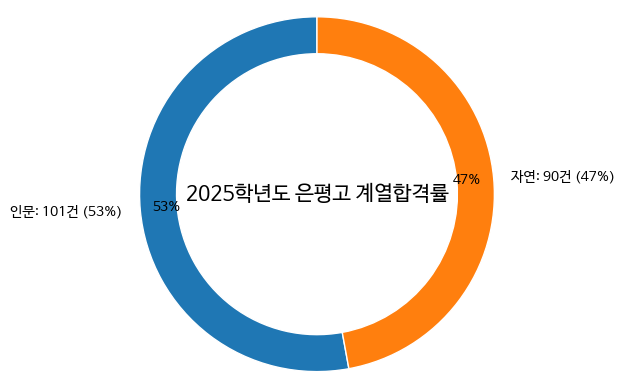

In [ ]:
#36. 4년제대 계열 합격률 도넛차트- 공통, 예체능을 인문으로 통합


import matplotlib.pyplot as plt
from tabulate import tabulate

# 지역, 최종, ace대학 제외
df_4year = df[(df.최종 == '합') & ~(df.대학.str.contains("대학교"))].copy()

# Combine '공통' and '예체능' into '인문' 계열
df_4year['계열'] = df_4year['계열'].replace(['공통', '예체능'], '인문')

# Group by '계열' and calculate the ratio
result = df_4year.groupby('계열').size().reset_index(name='합격자(건)')
result['비율(%)'] = (result['합격자(건)'] / result['합격자(건)'].sum() * 100).round(0).astype(int)  # Round to the nearest integer

# Rename the columns
result = result.rename(columns={'계열': '계열', '합격자(건)': '합격자(건)', '비율(%)': '비율(%)'})



# 시각화 부분 수정
fig, ax = plt.subplots()
ax.pie(result['합격자(건)'], labels=result['계열'] + ': ' + result['합격자(건)'].astype(str) + '건 (' + result['비율(%)'].astype(str) + '%)', startangle=90, radius=1.2, autopct='%1.0f%%', pctdistance=0.85, wedgeprops=dict(width=0.25, edgecolor='w'))

# 제목 추가
plt.text(0, 0, '2025학년도 은평고 계열합격률', fontsize=15, ha='center', va='center')


plt.show()

In [ ]:
#37. 계열별 합격률 반원 그래프 - 인문 합격률, 자연합격률

import matplotlib.pyplot as plt

from matplotlib.patches import Patch, Path, Wedge, Circle  # Circle 추가
import matplotlib.patches as patches


# '인문' 계열에서 '최종'이 '합'인 비율 계산
인문_합격자수 = df[(df['계열'] == '인문') & (df['최종'] == '합')].shape[0]
인문_전체 = df[df['계열'] == '인문'].shape[0]

ratio_inmun = (인문_합격자수 / 인문_전체) * 100 if 인문_전체 > 0 else 0
ratio_inmun = round(ratio_inmun)


# '자연' 계열에서 '최종'이 '합'인 비율 계산
자연_합격자수 = df[(df['계열'] == '자연') & (df['최종'] == '합')].shape[0]
자연_전체 = df[df['계열'] == '자연'].shape[0]

ratio_jayun = (자연_합격자수 / 자연_전체) * 100 if 자연_전체 > 0 else 0
ratio_jayun = round(ratio_jayun)


def draw_gauge_chart(ax, percentage, title, color):
    # 배경 원 그리기
    ax.add_patch(patches.Wedge(center=(0.5, 0.5), r=0.4, theta1=0, theta2=180, width=0.3, facecolor='lightgrey', edgecolor='black'))

    # 비율에 따른 원 그리기
    if percentage > 0:
        ax.add_patch(patches.Wedge(center=(0.5, 0.5), r=0.4, theta1=0, theta2=180 * percentage / 100, width=0.3, facecolor=color, edgecolor='black'))

    # 가운데 원(도넛 형태 만들기)
    ax.add_patch(Circle((0.5, 0.5), 0.1, transform=ax.transAxes, facecolor='white', edgecolor='black'))

    # 텍스트 및 타이틀 추가
    ax.text(0.5, 0.5, f'{percentage}%', horizontalalignment='center', verticalalignment='center', fontsize=14, transform=ax.transAxes)
    ax.set_title(title, fontsize=16)

    # 축 및 눈금 제거
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')


# 각 계열의 비율
ratios = {'인문': ratio_inmun, '자연': ratio_jayun}
colors = {'인문': '#4CAF50', '자연': '#FFC107'}

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

for ax, (title, percentage) in zip(axs, ratios.items()):
    draw_gauge_chart(ax, percentage, f'2025학년도 은평고 {title}계 합격률', colors[title])

plt.tight_layout()


plt.show()

In [ ]:
#38. 특정등급대별 학생명단

min = float(input('몇등급이상:'))
max = float(input('몇등급이상:'))

df_one = df[(df['전과목'] >= min) & (df['전과목'] < max)]
df_one = df_one.drop_duplicates('이름')
df_one = df_one[['학번', '전과목', '등급수능', '대학', '모집단위', '최종', '전형분류']].sort_values(by = '전과목')
df_one

In [ ]:
#39-1. 등급입력하면 등급대 합격자 나오는 그래프: 합격자 대학만 나옴

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd

## 데이터 불러오기
path = '/content/drive/MyDrive/python/habbul/'
df = pd.read_excel(f'{path}eunpyeong_2025_habbul.xlsx')

lownum = float(input("몇등급 이상:"))
highnum = float(input("몇등급 미만:"))

# 필터링 조건에 맞는 데이터 추출
df_one = df[(df['전과목'] >= lownum) & (df['전과목'] < highnum)].copy()

# 이름의 민감한 정보를 숨김 처리
df_one['이름'] = df_one['이름'].apply(lambda x: x[:2] + '0')

# '최종', '대학' 데이터를 각 '최종' 상태에 따라 집계
pivot_data = df_one.pivot_table(index='이름', columns='최종', values='학번', aggfunc='count', fill_value=0)
pivot_data = pivot_data[['합', '불']]  # '합'과 '불' 컬럼 순서 유지


# 대학 데이터만 추출
college_unit_data = df_one.groupby(['이름', '최종']).agg({
    '대학': lambda x: list(set(x)),
}).unstack(fill_value=[])

pivot_data.sort_values(by='합', ascending=True, inplace=True)  # '합' 기준으로 정렬

# 그래프 그리기
ax = pivot_data.plot(kind='bar', stacked=True, color=sns.color_palette('Dark2', 2))
plt.gca().spines[['top', 'right']].set_visible(False)
plt.title(f"2025학년도 E고 {int(round(lownum))}등급대 학생별 합격현황 (단위: 건)")
plt.xlabel('')

# 범례 순서 조절
handles, labels = ax.get_legend_handles_labels()
order = [1, 0]  # '불'이 먼저 나오고 '합'이 다음 나오도록 조정
plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order], title="최종", loc='upper left', bbox_to_anchor=(1, 1))

plt.xticks(rotation=30)

# '합'과 '불' 세그먼트 내에 '대학' 텍스트 추가, 폰트 크기 및 간격 조정
font_size = 6  # 폰트 크기 설정

text_offset = 0.7  # 텍스트 간의 수직 간격 조정
for idx, val in enumerate(pivot_data.index):
    sum_height = pivot_data.loc[val, '합']
    non_height = pivot_data.loc[val, '불']

    # '합' 막대에 대학 목록 표시
    if sum_height > 0:
        colleges = college_unit_data.loc[val, ('대학', '합')]
        for i, college in enumerate(colleges):
            plt.text(idx, sum_height - i * text_offset, college, ha='center', va='top', color='black', fontsize=font_size, rotation=0)

    # '불' 막대에 대학 목록 표시
    if non_height > 0:
        colleges = college_unit_data.loc[val, ('대학', '불')]
        for i, college in enumerate(colleges):
            plt.text(idx, sum_height + non_height - i * text_offset, college, ha='center', va='top', color='black', fontsize=font_size, rotation=0)

    # 점선 추가
    plt.hlines(y=sum_height, xmin=-0.5, xmax=len(pivot_data.index) - 0.5, colors='gray', linestyles='--', linewidth=0.5, alpha=0.3)

plt.show()

In [ ]:
#49. 특정계열의 합격률

adtype = input("계열(ex: 인문, 자연, 예체능)")

arts_students = df[df['계열'] == adtype]

# '최종' 열에서 '합'인 행 선택
pass_students = arts_students[arts_students['최종'] == '합']

# '계열' 열이 '예체능'인 학생들의 합격률 계산
pass_rate = len(pass_students) / len(arts_students) * 100

print(f"{adtype} 학생들의 합격률 {pass_rate}%")

In [ ]:
#50. 특정계열의 합격자

adtype = input("계열(ex: 인문, 자연, 예체능)")


# '계열' 열이 '예체능'인 행 필터링
arts_students = df[df['계열'] == adtype]

# '최종' 열에서 '합'인 행 선택
pass_students = arts_students[arts_students['최종'] == '합']


#반올림
pass_students['전과목'] = pass_students['전과목'].round(1)

# '최종' 열에서 '합'인 학생들의 '학번', '대학', '모집단위' 열 출력
pass_students_info = pass_students[['대학', '계열', '모집단위', '최종', '전과목']]


# '전과목' 열 값을 오름차순으로 정렬
pass_students_info_sorted = pass_students_info.sort_values(by='전과목')


# tabulate를 사용하여 결과 출력
print(tabulate(pass_students_info_sorted, headers='keys', tablefmt='plain', showindex=False))



#결과를 엑셀로 저장
path = '/content/drive/MyDrive/python/eunpyeong/result_excel/'
pass_students_info_sorted.to_excel(excel_writer= f'{path}예체능전형합격자_2025_은평고.xlsx')

In [ ]:
#51. 특정학과의 특정등급일때 결과

from tabulate import tabulate


major = input("모집단위:")
level_min =  float(input("높은 등급:"))
level_max = float(input("낮은 등급:"))


#4년제 지원자수(중복포함)
df_nurse = df[(df.모집단위.str.contains(major))]

#df_nurse = df_nurse[df_nurse['최종'] == '합']

df_nurse = df_nurse[(df_nurse['전과목'] > level_min) & (df_nurse['전과목'] < level_max) ]

df_nurse['전과목'] = df_nurse['전과목'].round(1)

df_nurse =  df_nurse[['전과목', '대학', '모집단위', '최종', '전형분류', '전형명', '전형방법']]



# tabulate를 사용하여 결과 출력
print(tabulate(df_nurse, headers='keys', tablefmt='plain', showindex=False))


#결과를 엑셀로 저장
path = '/content/drive/MyDrive/python/eunpyeong/result_excel/'
df_nurse.to_excel(excel_writer= f'{path}간호학과합격자_2025_3.5등급.xlsx')

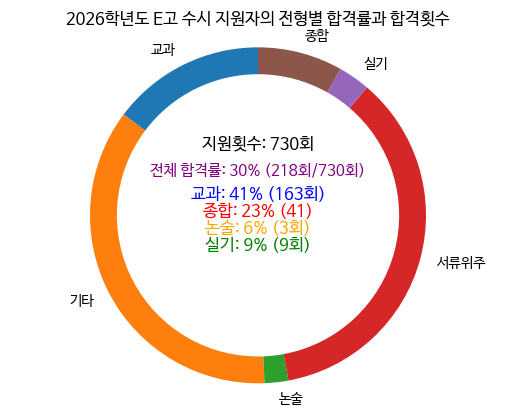

In [2]:
#52. 전형별 합격률과 합격횟수

import pandas as pd
import matplotlib.pyplot as plt

# 데이터 전처리: 전형분류 재분류
df_modified = df.copy()


# 조건 1: '전형분류'가 '학생부'이고 '전형방법'에 '100%'가 포함된 경우 → '교과'로 변경
df_modified.loc[(df_modified['전형분류'] == '학생부') &
                (df_modified['전형방법'].str.contains('100%', na=False)), '전형분류'] = '교과'


# 조건 2: '전형분류'가 '학생부'이고 '전형방법'에 '면접'이 포함된 경우 → '종합'으로 변경
df_modified.loc[(df_modified['전형분류'] == '학생부') &
                (df_modified['전형방법'].str.contains('면접', na=False)), '전형분류'] = '종합'


# 수시, 수시1차, 수시2차를 모두 포함
susi = ['수시', '수시1차', '수시2차']

# 조건에 따라 데이터 필터링 (df_modified 사용!)
filtered_df = df_modified[df_modified['지원시기'].str.contains("|".join(susi), na=False)]

# 각 전형분류별 합격자 수 계산
pass_counts = filtered_df.groupby('전형분류')['최종'].value_counts().unstack().fillna(0)['합']

# 각 전형분류별 합격률 계산 (전형분류 내 비율)
pass_rates = filtered_df.groupby('전형분류')['최종'].value_counts(normalize=True).unstack().fillna(0)['합']

# ✅ 추가: 전체 지원횟수 대비 최종 '합' 비율 계산
total_count = len(filtered_df)
total_pass_count = (filtered_df['최종'] == '합').sum()
total_pass_rate = total_pass_count / total_count * 100

# 도넛 차트 생성
labels = pass_rates.index
sizes = pass_rates.values * 100
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, startangle=90, wedgeprops=dict(width=0.16))

ax.axis('equal')

# 도넛 차트 내부에 비율과 빈도 표현
ax.text(0,  0.4, f"지원횟수: {total_count}회", ha='center', fontsize=12, color='black')
ax.text(0,  0.25, f"전체 합격률: {total_pass_rate:.0f}% ({total_pass_count}회/{total_count}회)", ha='center', fontsize=11, color='purple')  # ✅ 추가된 줄
ax.text(0,  0.1, f"교과: {pass_rates['교과'] * 100:.0f}% ({int(pass_counts['교과'])}회)", ha='center', fontsize=12, color='blue')
ax.text(0,  0.0, f"종합: {pass_rates['종합'] * 100:.0f}% ({int(pass_counts['종합'])})", ha='center', fontsize=12, color='red')
ax.text(0, -0.1, f"논술: {pass_rates['논술'] * 100:.0f}% ({int(pass_counts['논술'])}회)", ha='center', fontsize=12, color='orange')
ax.text(0, -0.2, f"실기: {pass_rates['실기'] * 100:.0f}% ({int(pass_counts['실기'])}회)", ha='center', fontsize=12, color='green')

plt.title('2026학년도 E고 수시 지원자의 전형별 합격률과 합격횟수')
plt.show()

In [ ]:
#53. 모집단위(학과)별 지원자

from tabulate import tabulate

path = '/content/drive/MyDrive/python/habbul/'
df = pd.read_excel(f'{path}eunpyeong_2025_habbul.xlsx')

major = input("모집단위:")

#4년제 지원자수(중복포함)
uni_apply = df[(df.모집단위.str.contains(major))]

print(uni_apply[['대학', '모집단위', '최종', '전과목', '등급수능']])

In [ ]:
#54. 등급대별 수시 합격자 확인

from tabulate import tabulate


##  데이터 부르기
path = '/content/drive/MyDrive/python/habbul/'
df = pd.read_excel(f'{path}eunpyeong_2025_habbul.xlsx')


level_min =  float(input("높은 등급:"))
level_max = float(input("낮은 등급:"))

apply_type = input("전형분류:")
result = input("최종(합, 불):")


#4년제 지원자수(중복포함)
df_nurse = df[(df.전형분류.str.contains(apply_type))]

df_nurse = df_nurse[df_nurse['최종'] == result]

df_nurse = df_nurse[(df_nurse['전과목'] >= level_min) & (df_nurse['전과목'] < level_max) ]

df_nurse['전과목'] = df_nurse['전과목'].round(1)

df_nurse =  df_nurse[['이름', '전과목', '대학', '모집단위', '최종', '전형분류', '전형명', '전형방법']]

df_nurse_num = len(df_nurse)


print(f"종합전형 {result}건수 {df_nurse_num}건")

# tabulate를 사용하여 결과 출력
print(tabulate(df_nurse, headers='keys', tablefmt='plain', showindex=False))

In [ ]:
#55. 등급대별 수능최저등급 충족여부 - 내신등급 추가


import numpy as np
import pandas as pd
from tabulate import tabulate
import math  # 절사를 위해 math 모듈 추가

# 입력 받기
level_min = float(input("내신 높은 등급:"))
level_max = float(input("내신 낮은 등급:"))

choice = input("탐구1과 탐구2의 평균등급을 사용하시겠습니까? (예/아니오): ")

# '수능'을 제외한 값 필터링
df_filtered = df[df['전형분류'] != '수능']

# 범위에 따른 '전과목' 값 필터링
df_level = df_filtered[(df_filtered['전과목'] >= level_min) & (df_filtered['전과목'] < level_max)].copy()

# 데이터 프레임 필터링
df_level = df_level.drop_duplicates('이름')
df_level = df_level[['이름', '전과목', '국어_등급', '수학_등급', '영어_등급', '선택1_등급', '선택2_등급']]

# '이름' 열의 값을 첫 글자만 남기고 나머지는 '*'로 대체
#df_level['이름'] = df_level['이름'].apply(lambda x: x[:1] + '*' * (len(x) - 1) if len(x) >= 2 else x)

# 열 이름 변경
df_level.rename(columns={'선택1_등급': '탐구1_등급', '선택2_등급': '탐구2_등급'}, inplace=True)


# NaN 값을 0으로 대체
df_level.fillna(0, inplace=True)

# 평균 사용 여부에 따른 조건 처리
if choice.lower() == '예':
    trunc_choice = input("탐구1과 탐구2의 평균을 절사하시겠습니까? (예/아니오): ")
    if trunc_choice.lower() == '예':
        df_level['탐구_등급'] = df_level[['탐구1_등급', '탐구2_등급']].mean(axis=1).apply(math.floor)
    else:
        df_level['탐구_등급'] = df_level[['탐구1_등급', '탐구2_등급']].mean(axis=1)
    columns = ['국어_등급', '수학_등급', '영어_등급', '탐구_등급']
else:
    columns = ['국어_등급', '수학_등급', '영어_등급', '탐구1_등급', '탐구2_등급']

# 최저합 계산
df_level['4합'] = df_level[columns].apply(lambda x: x.nsmallest(4).sum(), axis=1)
df_level['3합'] = df_level[columns].apply(lambda x: x.nsmallest(3).sum(), axis=1)
df_level['2합'] = df_level[columns].apply(lambda x: x.nsmallest(2).sum(), axis=1)

# 결과 출력
headers = ['전과목', '국어_등급', '수학_등급', '영어_등급']
if choice.lower() == '예':
    headers.append('탐구_등급')
else:
    headers.extend(['탐구1_등급', '탐구2_등급'])
headers.extend(['2합', '3합', '4합'])

#전과목 순으로 오름차순
df_level = df_level.sort_values(by='전과목')

tab = tabulate(df_level[headers], headers='keys', tablefmt='plain', showindex=False)
print()
print(tab)

# 데이터 프레임으로 전환은 불필요함
# 엑셀로 저장
path = '/content/drive/MyDrive/python/eunpyeong/result_habbul/'
df_level.to_excel(excel_writer=f'{path}{level_min}등급대_수능최저등급조합_2025_은평고_익명.xlsx', index=False)

In [ ]:
#55-1. 수능최저등급 개인별 자동확인

import numpy as np
from tabulate import tabulate
import math  # 절사를 위해 math 모듈 추가

# 사용자 입력 받기
name = input('이름: ')
choice = input("탐구1과 탐구2'의 평균등급을 사용하시겠습니까? (예/아니오): ")

# 데이터 프레임 필터링
df_kim = df[df['이름'] == name]
df_kim = df_kim.drop_duplicates('이름')
df_kim = df_kim[['국어_등급', '수학_등급', '영어_등급', '선택1_등급', '선택2_등급']]

# 열 이름 변경
df_kim.rename(columns={'선택1_등급': '탐구1_등급', '선택2_등급': '탐구2_등급'}, inplace=True)

# 평균 사용 여부에 따른 조건 처리
if choice.lower() == '예':
    trunc_choice = input("탐구1과 탐구2의 평균을 절사하시겠습니까? (예/아니오): ")
    if trunc_choice.lower() == '예':
        df_kim['탐구_등급'] = df_kim[['탐구1_등급', '탐구2_등급']].mean(axis=1).apply(math.floor)
    else:
        df_kim['탐구_등급'] = df_kim[['탐구1_등급', '탐구2_등급']].mean(axis=1)
    columns = ['국어_등급', '수학_등급', '영어_등급', '탐구_등급']
else:
    columns = ['국어_등급', '수학_등급', '영어_등급', '탐구1_등급', '탐구2_등급']

# 최저합 계산
df_kim['4합'] = df_kim[columns].apply(lambda x: x.nsmallest(4).sum(), axis=1)
df_kim['3합'] = df_kim[columns].apply(lambda x: x.nsmallest(3).sum(), axis=1)
df_kim['2합'] = df_kim[columns].apply(lambda x: x.nsmallest(2).sum(), axis=1)

# 결과 출력
headers = ['국어_등급', '수학_등급', '영어_등급']
if choice.lower() == '예':
    headers.append('탐구_등급')
else:
    headers.extend(['탐구1_등급', '탐구2_등급'])
headers.extend(['2합', '3합', '4합'])
tab = tabulate(df_kim[headers], headers='keys', tablefmt='plain', showindex=False)
print() ; print(tab)

In [ ]:
#56-1. 등급대별 수시 지원조합: 익명처리

import pandas as pd
from tabulate import tabulate

##  데이터 부르기
path = '/content/drive/MyDrive/python/habbul/'
df = pd.read_excel(f'{path}eunpyeong_2025_habbul.xlsx')

# 입력 받기
level_min = float(input("높은 등급:"))
level_max = float(input("낮은 등급:"))

# '수능'을 제외한 값 필터링
df_filtered = df[df['전형분류'] != '수능']

# 범위에 따른 '전과목' 값 필터링
df_level = df_filtered[(df_filtered['전과목'] >= level_min) & (df_filtered['전과목'] < level_max)].copy()

# 전과목 내신 소수점 첫째자리까지 표시
df_level['전과목'] = df_level['전과목'].round(1)

# 이름을 첫 글자만 남기고 나머지는 별표로 처리한 새로운 열 추가
df_level['익명'] = df_level['이름'].apply(lambda x: x[0] + '*' * (len(x) - 1))


# '전형분류'의 빈도수를 카운트하여 피벗 테이블 생성
pivot_table = df_level.pivot_table(index=('이름', '전과목', '익명'), columns='전형분류', aggfunc='size', fill_value=0)


# '익명', '전과목', '교과', '종합', '실기', '논술' 열로 정렬
result = pivot_table.reset_index().reindex(columns=['익명', '전과목', '교과', '종합', '실기', '논술'], fill_value=0)

# '전과목' 열의 값의 오름차순으로 정렬
result = result.sort_values(by='전과목').reset_index(drop=True)

# 교과, 종합, 실기, 논술의 평균 계산
averages = result[['교과', '종합', '실기', '논술']].mean().round(1)
average_row = pd.DataFrame([['평균', '', averages['교과'], averages['종합'], averages['실기'], averages['논술']]],
                           columns=result.columns)

# 결과에 평균 행 추가
result = pd.concat([result, average_row], ignore_index=True)

# '지원총횟수' 열 추가 및 값 계산
result['지원총횟수'] = result[['교과', '종합', '실기', '논술']].sum(axis=1)

# 결과 출력
print(tabulate(result, headers='keys', tablefmt='plain'))

# 데이터 프레임으로 전환
result_df = pd.DataFrame(result)

# 결과를 엑셀로 저장
path = '/content/drive/MyDrive/python/eunpyeong/result_habbul/'
result_df.to_excel(excel_writer=f'{path}{level_min}등급대_수시전형_지원조합_2025_은평고_익명.xlsx', index=False)